In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
os.chdir('../..')
os.getcwd()

'/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency'

In [3]:
seqImpact = pd.read_csv('output/data/sanityCheck/seqImpact_predictions.csv') # checks the impact of the sequences on predictions (extraFeatures the extraFeatImpact for all sequences)
extraFeatImpact = pd.read_csv('output/data/sanityCheck/extraFeatImpact_predictions.csv') # checks the impact of the extraFeatures on predictions (sequence the extraFeatImpact for all extraFeatures)
utr5Impact = pd.read_csv('output/data/sanityCheck/5UTRImpact_predictions.csv') # checks the impact of the 3' UTR on predictions (5' UTR and extraFeatures the extraFeatImpact for all while 3' UTR are the seqImpactinals)
utr3Impact = pd.read_csv('output/data/sanityCheck/3UTRImpact_predictions.csv') # checks the impact of the 5' UTR on predictions (3' UTR and extraFeatures the extraFeatImpact for all while 5' UTR are the seqImpactinals)


# # merge the two dataframes on sequenceCounts
# merged = pd.merge(seqImpact, extraFeatImpact, on='sequenceCount', suffixes=('_seqImpact', '_extraFeatImpact'), how='outer')
# # Add suffix to utr5Impact columns before merging to avoid naming conflicts
# utr5Impact = utr5Impact.add_suffix('_utr5Impact')
# utr5Impact = utr5Impact.rename(columns={'sequenceCount_utr5Impact': 'sequenceCount'})
# merged = pd.merge(merged, utr5Impact, on='sequenceCount', how='outer')
# merged = pd.merge(merged, utr3Impact, on='sequenceCount', suffixes=('', '_utr3Impact'), how='outer')

In [4]:
print(seqImpact)
print(extraFeatImpact)
print(utr5Impact)
print(utr3Impact)

               trID  actual  originalPrediction  perturbedPrediction  \
0       FBtr0084967   0.845                0.73                 0.97   
1       FBtr0084967   0.845                0.73                 0.74   
2       FBtr0084967   0.845                0.73                 0.73   
3       FBtr0084967   0.845                0.73                 0.71   
4       FBtr0084967   0.845                0.73                 0.92   
...             ...     ...                 ...                  ...   
810895  FBtr0334627   0.725                0.51                 0.53   
810896  FBtr0334627   0.725                0.51                 0.48   
810897  FBtr0334627   0.725                0.51                 0.55   
810898  FBtr0334627   0.725                0.51                 0.61   
810899  FBtr0334627   0.725                0.51                 0.55   

        sequenceCount  
0                   1  
1                   2  
2                   3  
3                   4  
4              

In [5]:
eGroups = [f'{a}_{o}' for a,o in zip(extraFeatImpact['actual'],extraFeatImpact['originalPrediction'])]
eGroups_fixed = []
prevGroup = None
counts = {}
for i, group in enumerate(eGroups):
    if group != prevGroup:
        if group not in counts:
            counts[group] = 0
        else:
            counts[group] += 1
    eGroups_fixed.append(group+f'_{counts[group]}')
    prevGroup = group

print(len(seqImpact['trID'].unique()))
print(len(set(eGroups_fixed)))


901
901


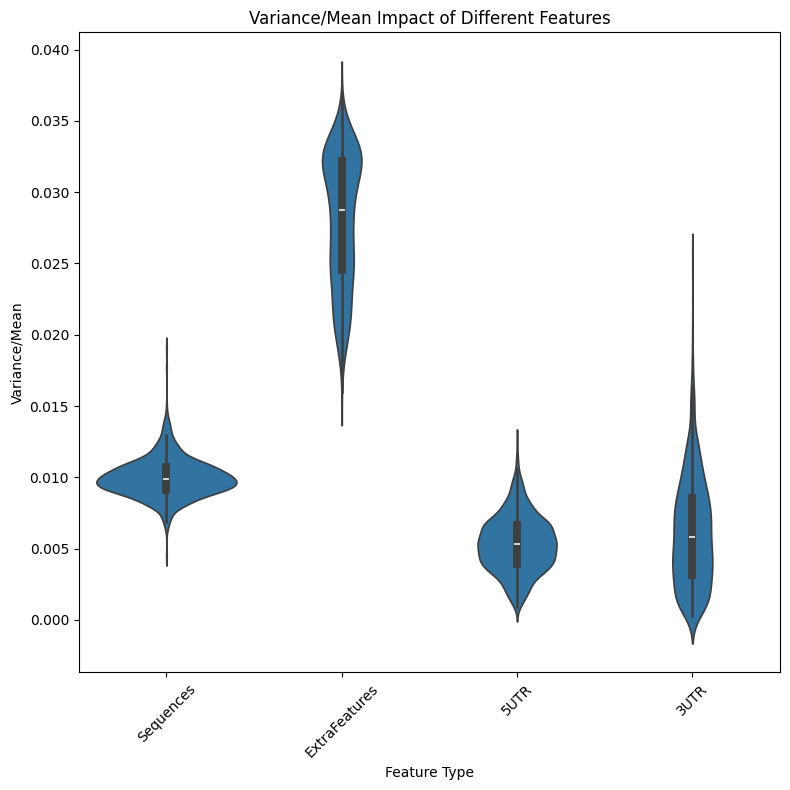

0.009977386814691527 0.028064549627092854 0.005333717548269304 0.006180189335355439


In [34]:
sImp = seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()**2/ seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).mean()
eImp = extraFeatImpact['perturbedPrediction'].groupby(eGroups_fixed).std()**2/ extraFeatImpact['perturbedPrediction'].groupby(eGroups_fixed).mean()
u5Imp = utr5Impact['perturbedPrediction'].groupby(utr5Impact['trID']).std()**2/ utr5Impact['perturbedPrediction'].groupby(utr5Impact['trID']).mean()
u3Imp = utr3Impact['perturbedPrediction'].groupby(utr3Impact['trID']).std()**2/ utr3Impact['perturbedPrediction'].groupby(utr3Impact['trID']).mean()
# Create dataframe for plotting
plot_data_imp = pd.DataFrame({
    'Impact': list(sImp) + list(eImp) + list(u5Imp) + list(u3Imp),
    'Feature': ['Sequences'] * len(sImp) + 
               ['ExtraFeatures'] * len(eImp) + 
               ['5UTR'] * len(u5Imp) + 
               ['3UTR'] * len(u3Imp)
})

# Create violin plot
plt.figure(figsize=(8, 8))
sns.violinplot(data=plot_data_imp, x='Feature', y='Impact')
plt.title('Variance/Mean Impact of Different Features')
plt.ylabel('Variance/Mean')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/model_feature_impact_violin_plot.pdf')
plt.show()

print(np.mean(sImp), np.mean(eImp), np.mean(u5Imp), np.mean(u3Imp))


In [7]:
print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean(abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction'])):.4f}")

print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean(abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction'])):.4f}")


print("\n(impact of 5UTR) :")
print(f"  {np.mean(abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean(abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction'])):.4f}")


(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0823
(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1311

(impact of 5UTR) :
  0.0553

(impact of 3UTR) :
  0.0638


# Identify seqs with large deviations from the original prediction
This should mean that the original sequence is required for proper prediction. 

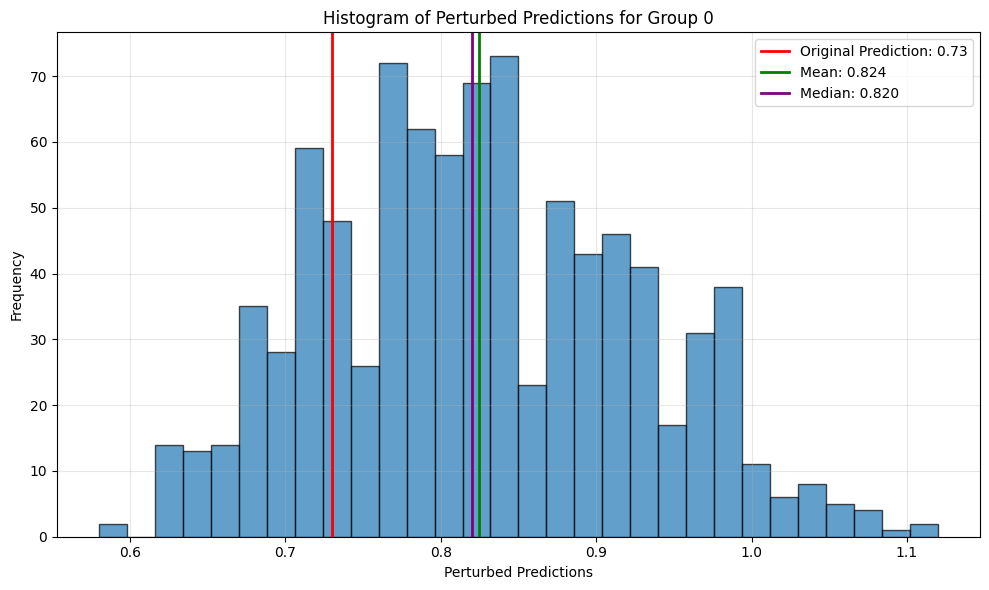

In [ ]:
import matplotlib.pyplot as plt

seqImpact.sort_values(by='trID', inplace=True)

plt.figure(figsize=(10, 6))
group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == seqImpact['trID'][0]]
original_prediction = seqImpact['originalPrediction'][0]

plt.hist(group_0_predictions, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
plt.axvline(x=group_0_predictions.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {group_0_predictions.mean():.3f}')
plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
plt.xlabel('Perturbed Predictions')
plt.ylabel('Frequency')
plt.title('Histogram of Perturbed Predictions for Group 0')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
z = (seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean()-seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).mean())/(seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()/np.sqrt(seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).count()))
z_median = (seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean()-seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).median())/(seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()/np.sqrt(seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).count()))
len(z)
#print([i for i in z if i != 0])

901

In [10]:
print(seqImpact['trID'].unique())
print(seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean())

['FBtr0070007' 'FBtr0070041' 'FBtr0070046' 'FBtr0070078' 'FBtr0070098'
 'FBtr0070119' 'FBtr0070141' 'FBtr0070151' 'FBtr0070159' 'FBtr0070207'
 'FBtr0070216' 'FBtr0070270' 'FBtr0070315' 'FBtr0070331' 'FBtr0070347'
 'FBtr0070372' 'FBtr0070401' 'FBtr0070405' 'FBtr0070414' 'FBtr0070431'
 'FBtr0070610' 'FBtr0070611' 'FBtr0070627' 'FBtr0070644' 'FBtr0070652'
 'FBtr0070671' 'FBtr0070680' 'FBtr0070681' 'FBtr0070698' 'FBtr0070699'
 'FBtr0070748' 'FBtr0070799' 'FBtr0070829' 'FBtr0070963' 'FBtr0070964'
 'FBtr0070980' 'FBtr0071003' 'FBtr0071004' 'FBtr0071048' 'FBtr0071073'
 'FBtr0071089' 'FBtr0071096' 'FBtr0071102' 'FBtr0071105' 'FBtr0071107'
 'FBtr0071189' 'FBtr0071221' 'FBtr0071223' 'FBtr0071289' 'FBtr0071315'
 'FBtr0071358' 'FBtr0071366' 'FBtr0071402' 'FBtr0071415' 'FBtr0071451'
 'FBtr0071461' 'FBtr0071487' 'FBtr0071500' 'FBtr0071520' 'FBtr0071541'
 'FBtr0071547' 'FBtr0071548' 'FBtr0071576' 'FBtr0071583' 'FBtr0071592'
 'FBtr0071618' 'FBtr0071622' 'FBtr0071632' 'FBtr0071637' 'FBtr0071747'
 'FBtr

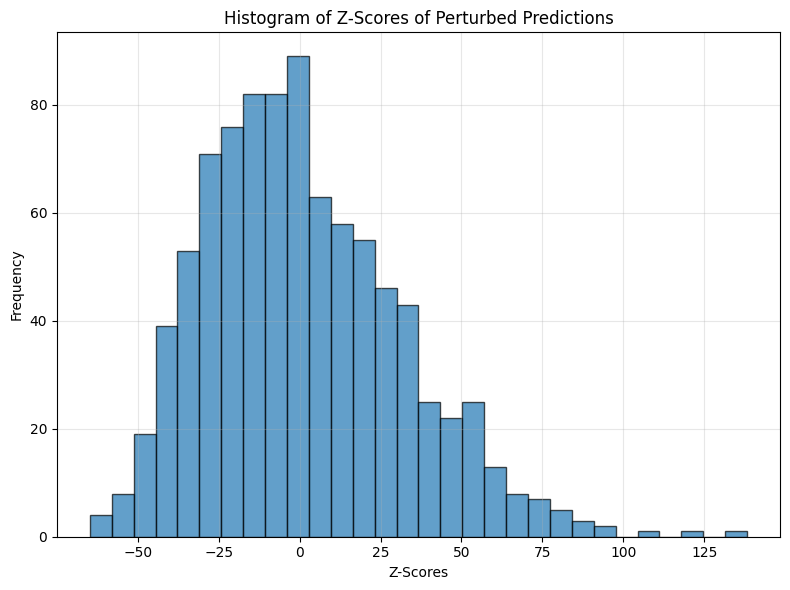

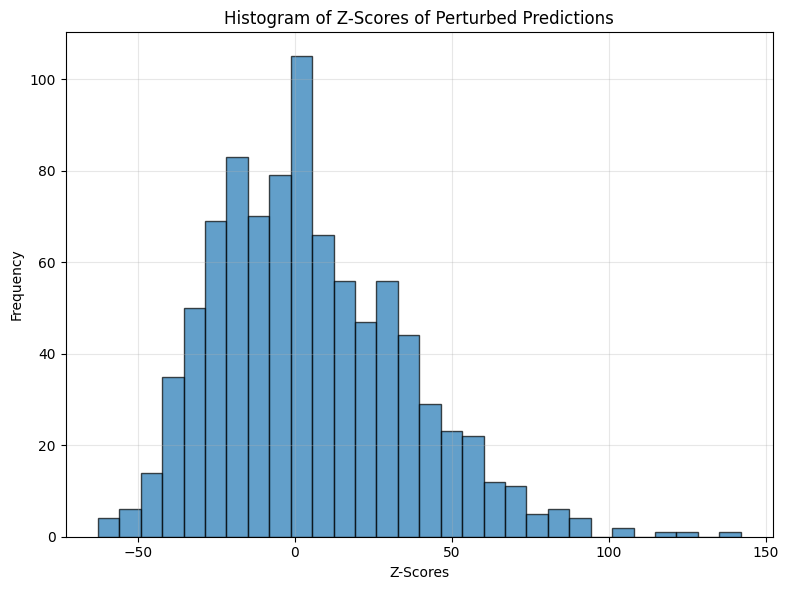

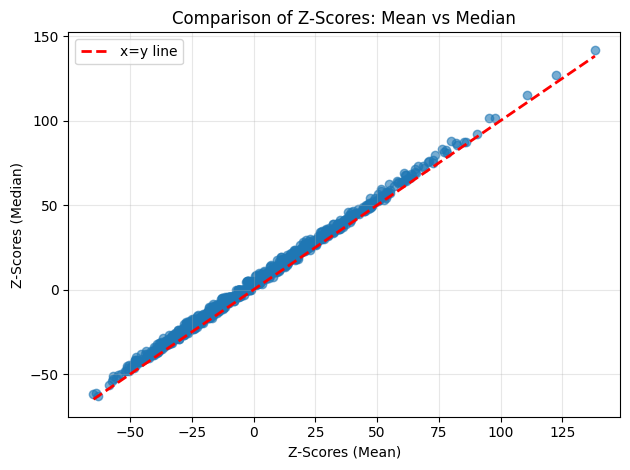

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(z, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Z-Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Z-Scores of Perturbed Predictions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
plt.hist(z_median, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Z-Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Z-Scores of Perturbed Predictions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(z, z_median, alpha=0.6)
plt.plot([z.min(), z.max()], [z.min(), z.max()], 'r--', linewidth=2, label='x=y line')
plt.xlabel('Z-Scores (Mean)')
plt.ylabel('Z-Scores (Median)')
plt.title('Comparison of Z-Scores: Mean vs Median')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
zHigh = [i for i in range(len(z)) if z[i] > 90]
zLow = [i for i in range(len(z)) if z[i] < - 55]
print(zHigh)
print(zLow)

[26, 36, 202, 460, 718, 719]
[48, 54, 91, 142, 256, 268, 525, 563, 885]


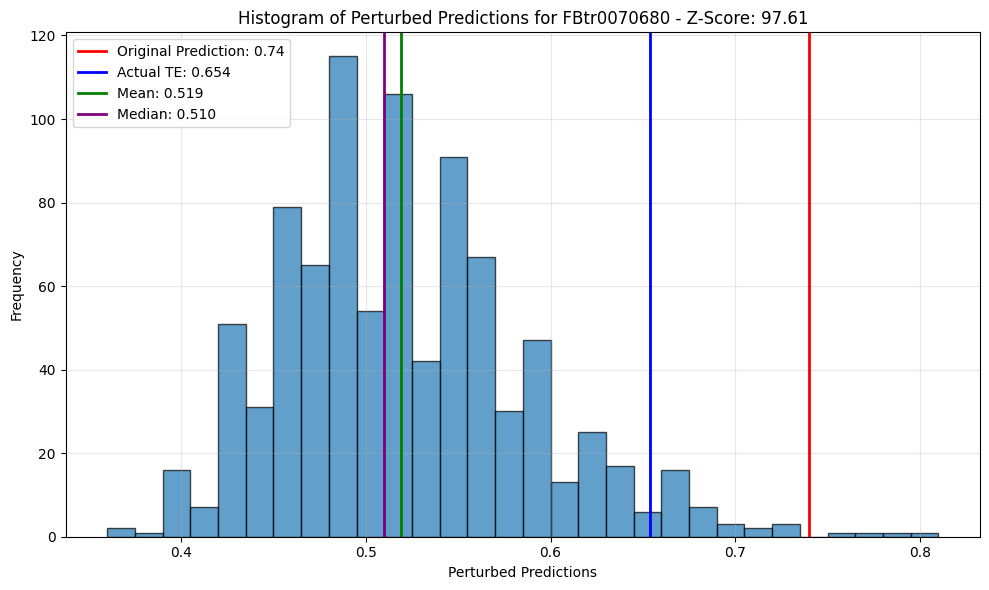

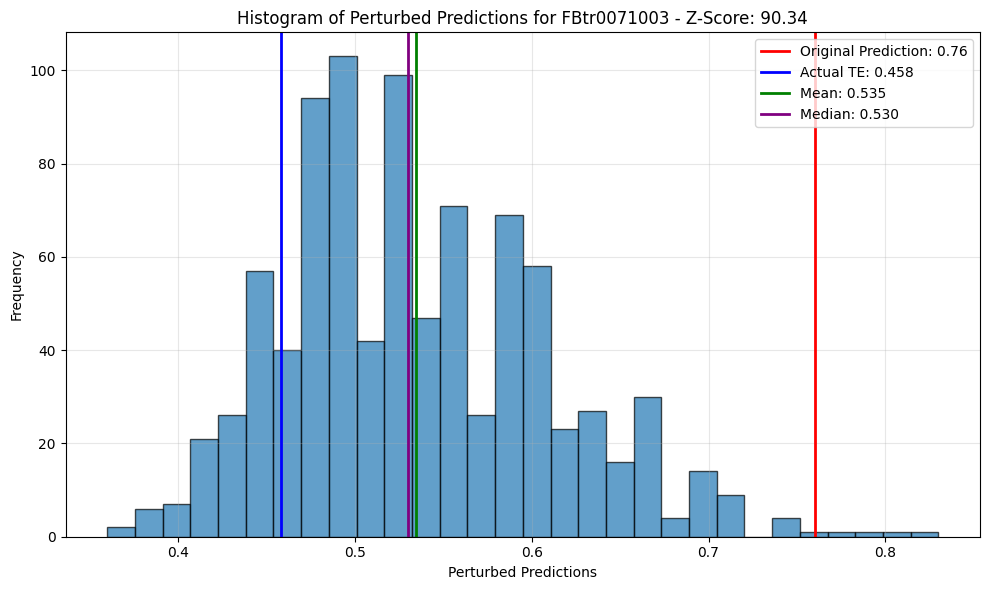

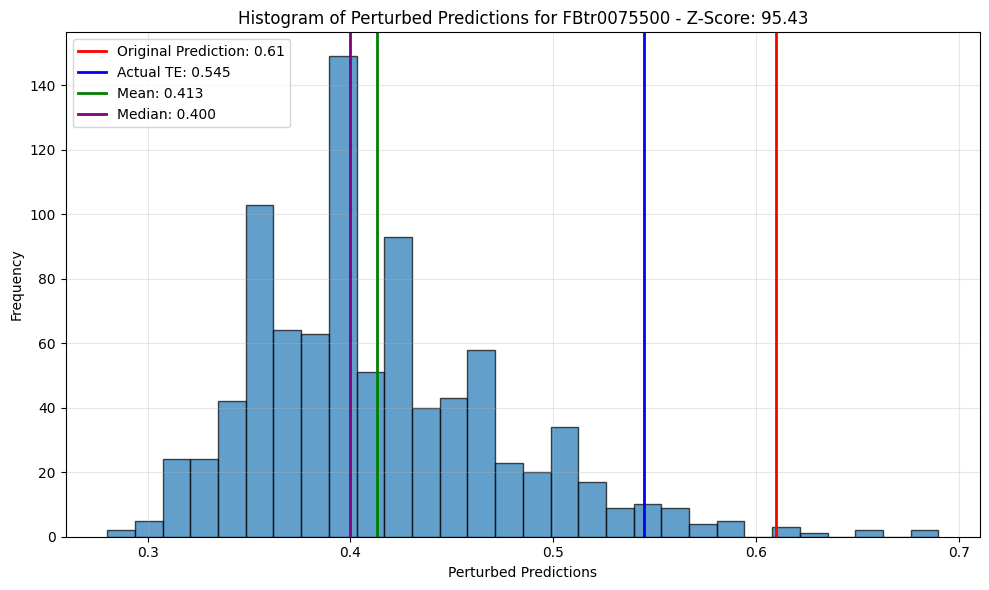

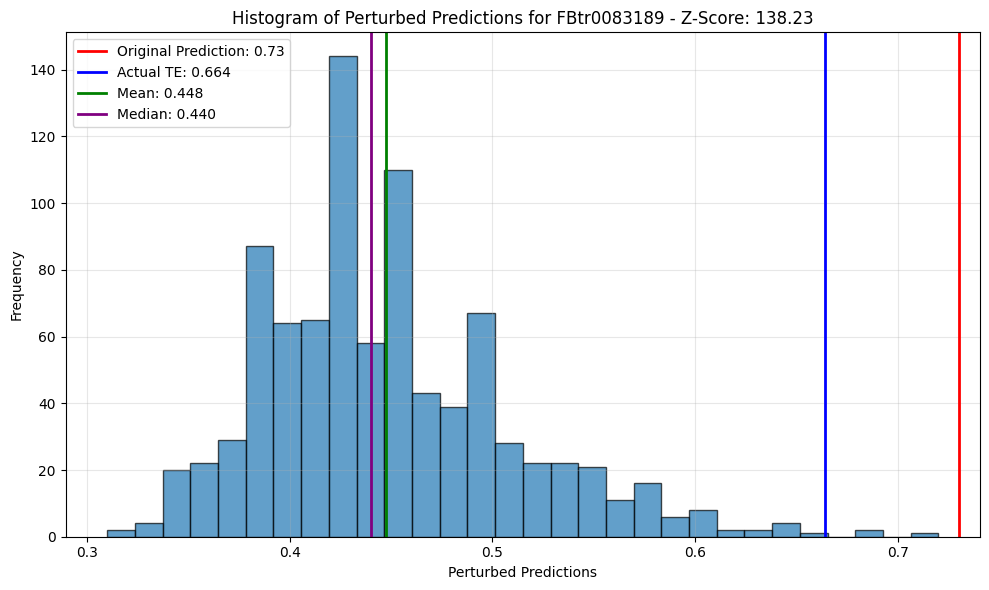

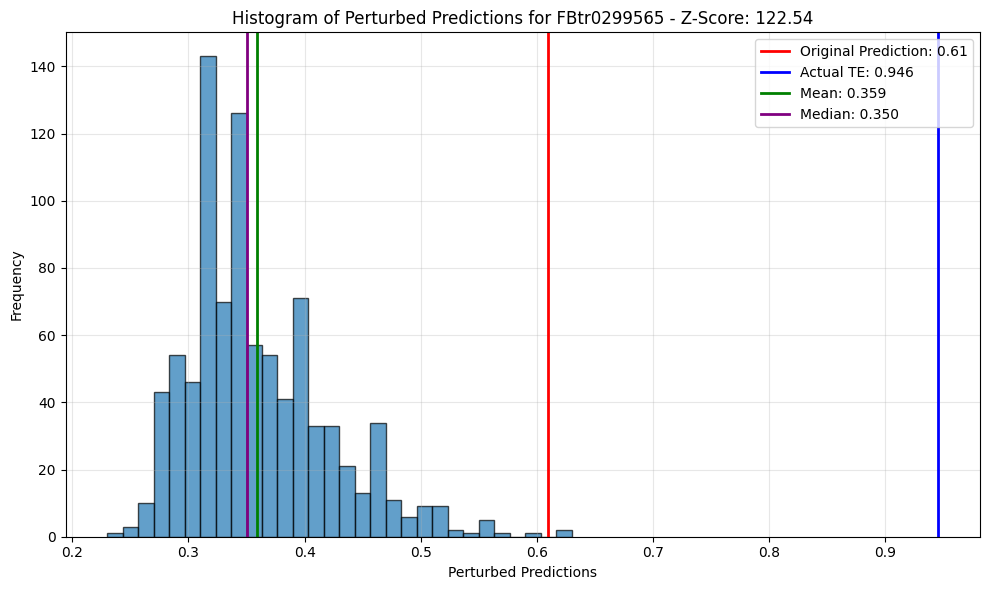

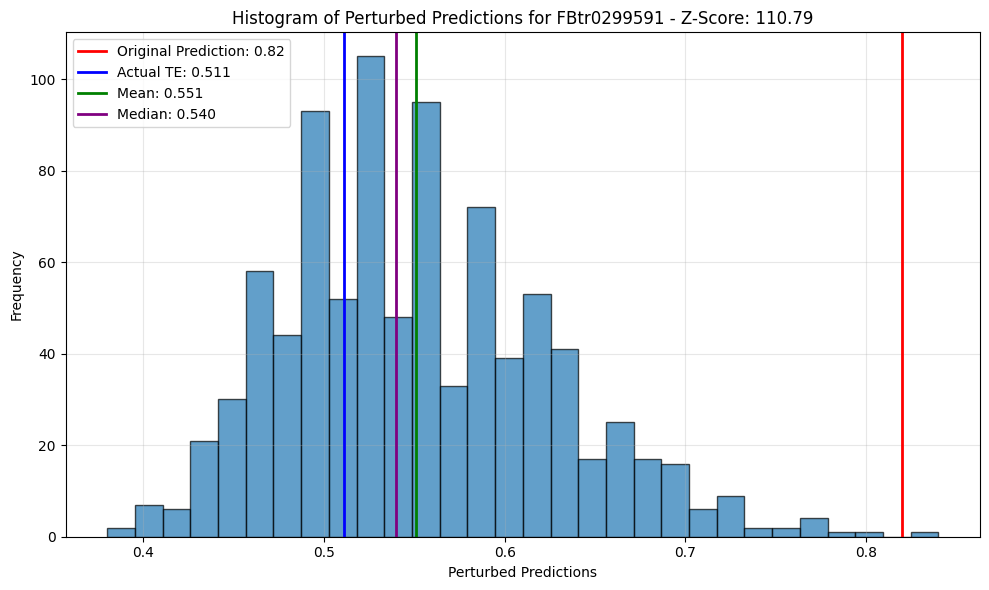

In [13]:
for i in zHigh:
    plt.figure(figsize=(10, 6))
    group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == seqImpact['trID'].unique()[i]]
    original_prediction = seqImpact['originalPrediction'][seqImpact['trID'] == seqImpact['trID'].unique()[i]].values[0]
    actualTE = seqImpact['actual'][seqImpact['trID'] == seqImpact['trID'].unique()[i]].values[0]

    plt.hist(group_0_predictions, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
    plt.axvline(x=actualTE, color='blue', linestyle='-', linewidth=2, label=f'Actual TE: {actualTE}')
    plt.axvline(x=group_0_predictions.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {group_0_predictions.mean():.3f}')
    plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
    plt.xlabel('Perturbed Predictions')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Perturbed Predictions for {seqImpact["trID"].unique()[i]} - Z-Score: {z[i]:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

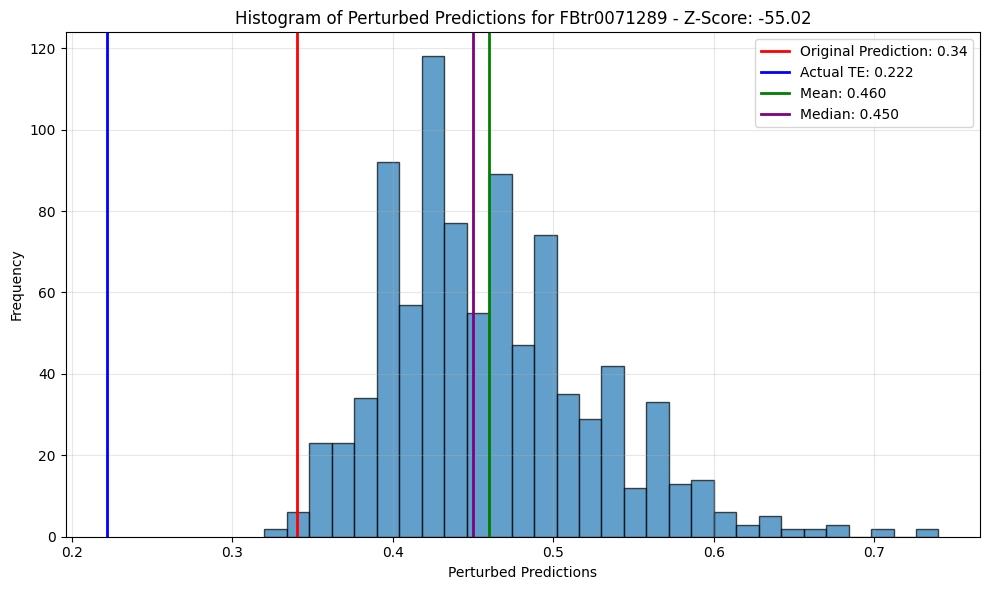

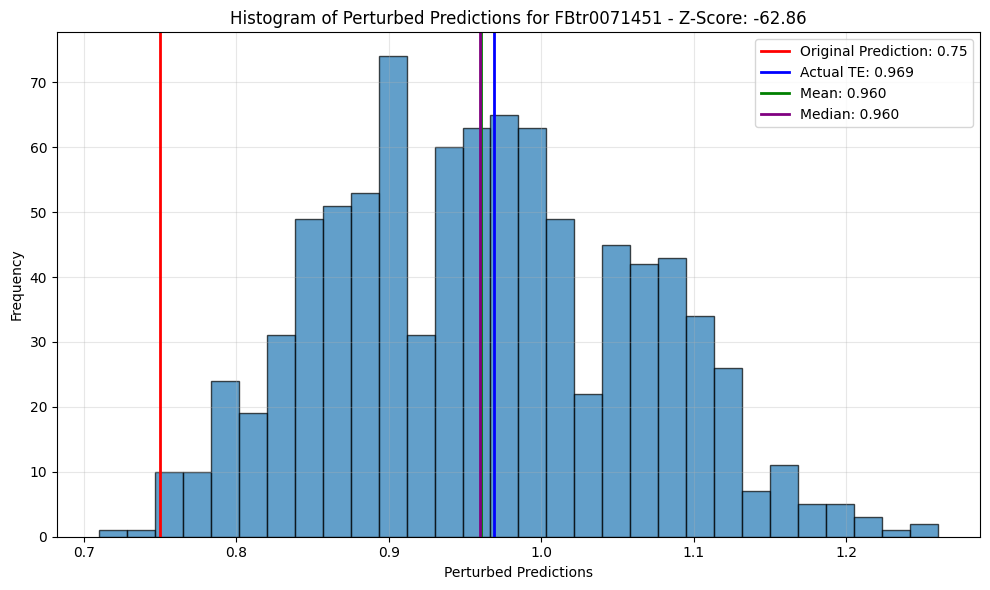

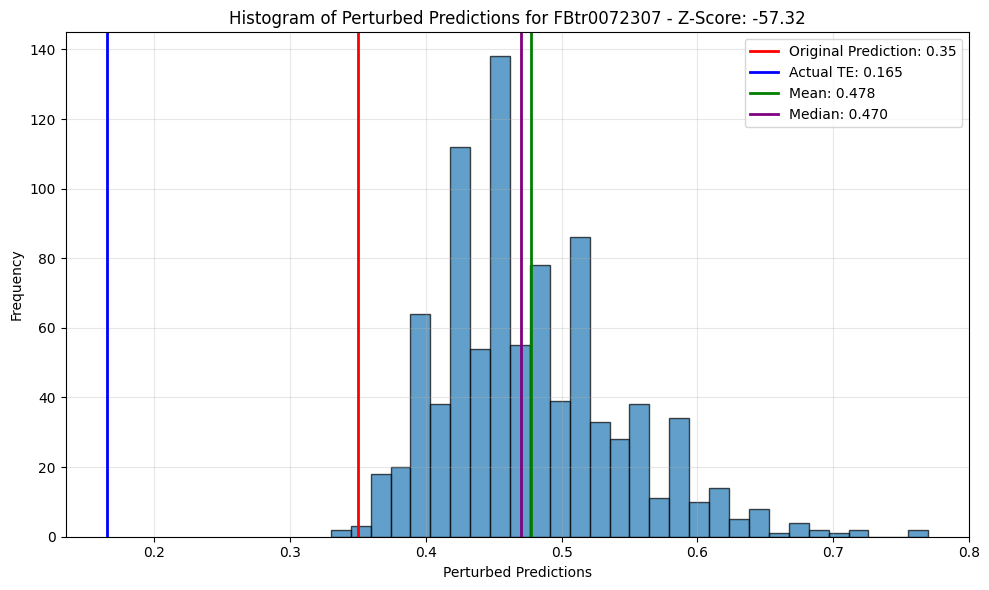

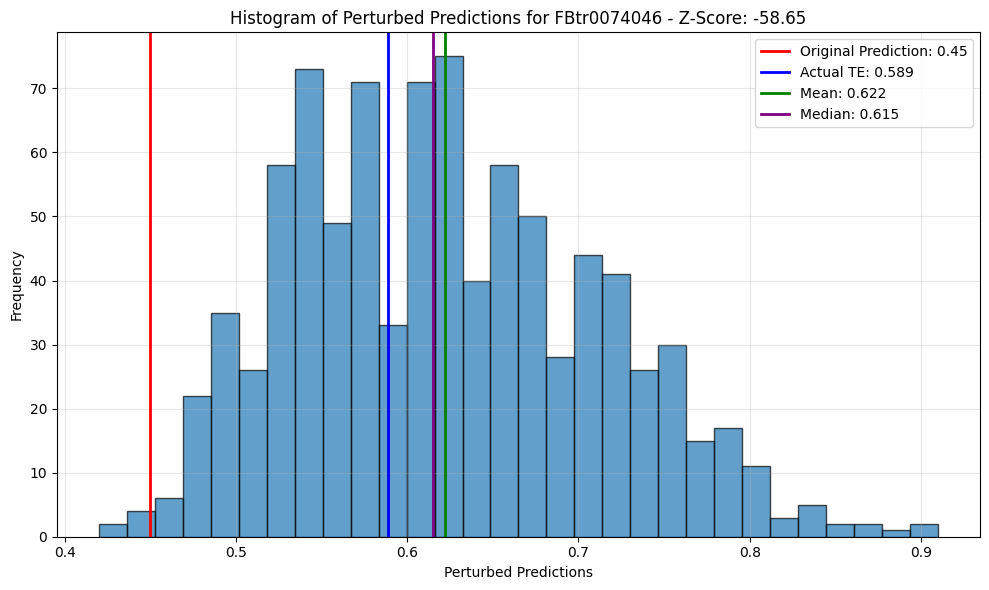

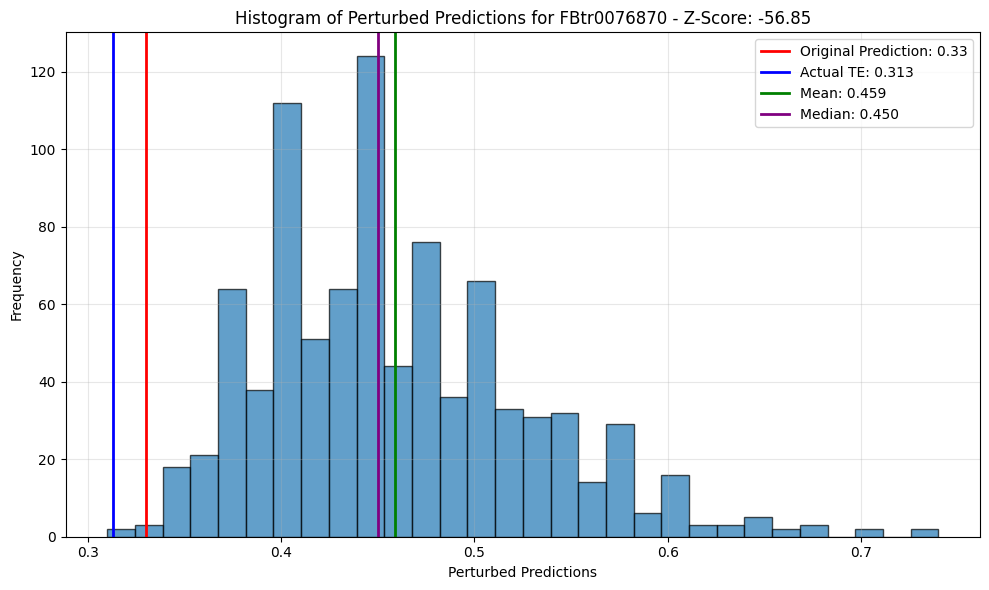

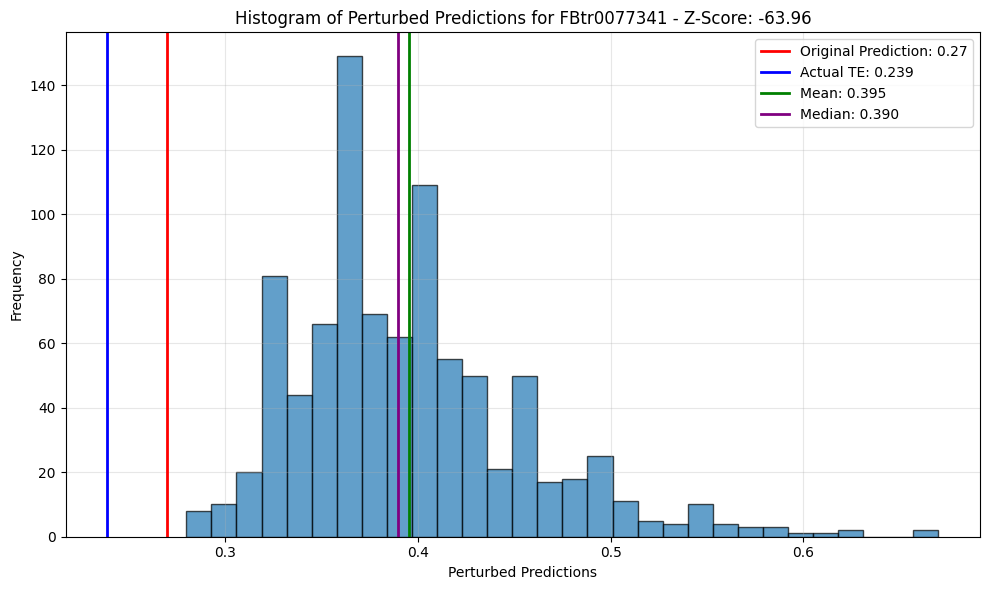

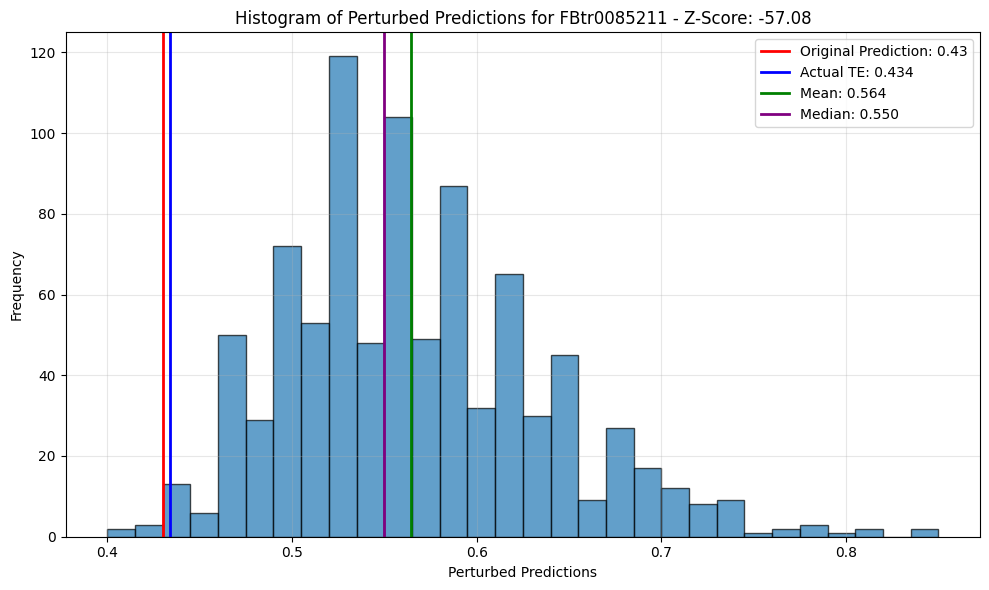

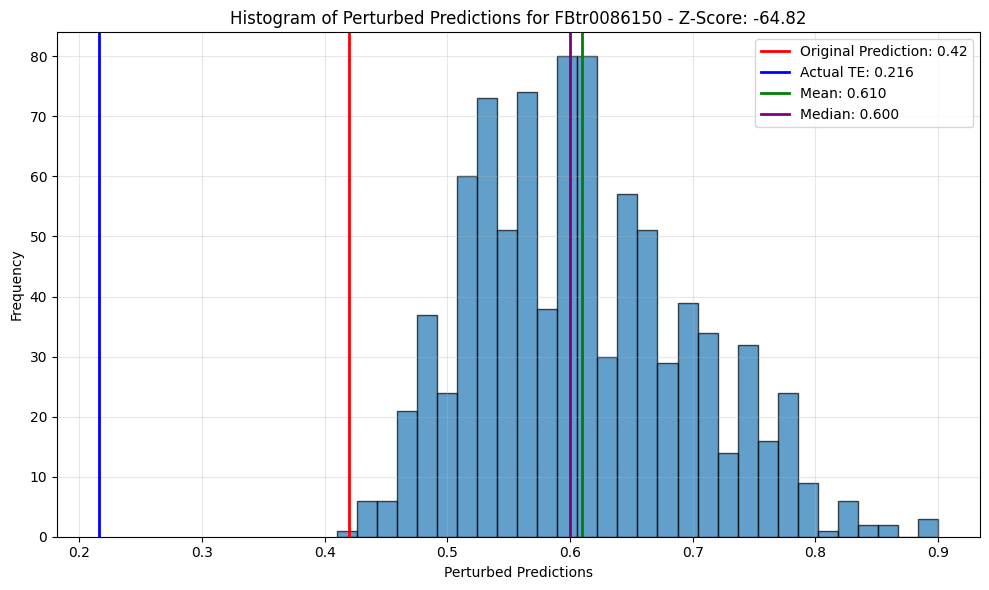

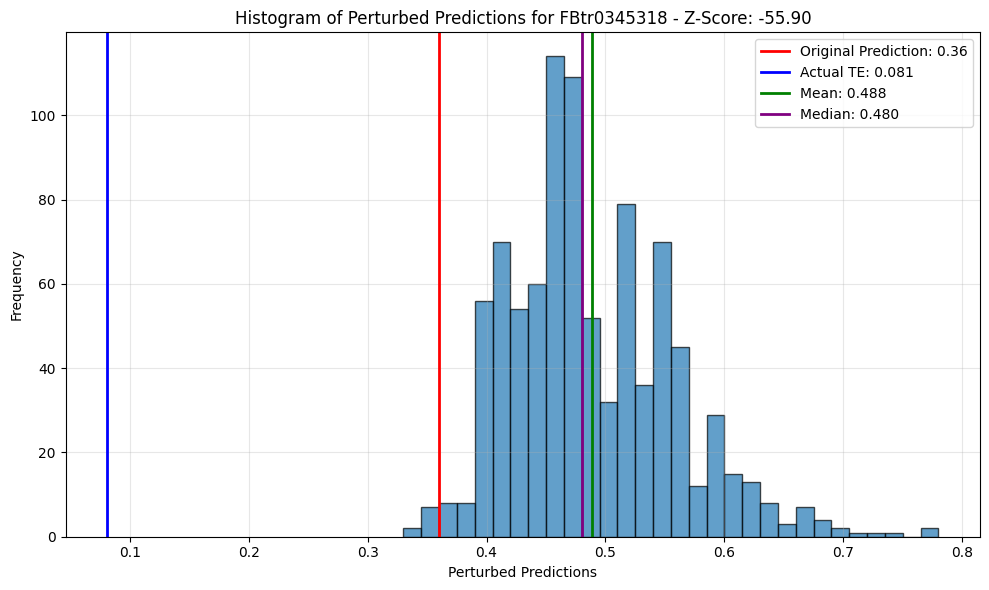

In [14]:
for i in zLow:
    plt.figure(figsize=(10, 6))
    group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == seqImpact['trID'].unique()[i]]  # Assuming you want to plot for the first group
    original_prediction = seqImpact['originalPrediction'][seqImpact['trID'] == seqImpact['trID'].unique()[i]].values[0]
    actualTE = seqImpact['actual'][seqImpact['trID'] == seqImpact['trID'].unique()[i]].values[0]

    plt.hist(group_0_predictions, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
    plt.axvline(x=actualTE, color='blue', linestyle='-', linewidth=2, label=f'Actual TE: {actualTE}')
    plt.axvline(x=group_0_predictions.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {group_0_predictions.mean():.3f}')
    plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
    plt.xlabel('Perturbed Predictions')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Perturbed Predictions for {seqImpact["trID"].unique()[i]} - Z-Score: {z[i]:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Identify seqs with high variability in predictions
Large variability should mean that the sequence has a large influence on the prediction. 

In [15]:
#from scipy.stats import levene
#stat, p = levene(seqImpact['perturbedPrediction'][group_ids == 0], seqImpact['perturbedPrediction'][group_ids == 1])

variance = seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()/seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).mean()
variance_sqrd = seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()**2/seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).mean()
variance_origPred = seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std()/seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean()
len(variance)


901

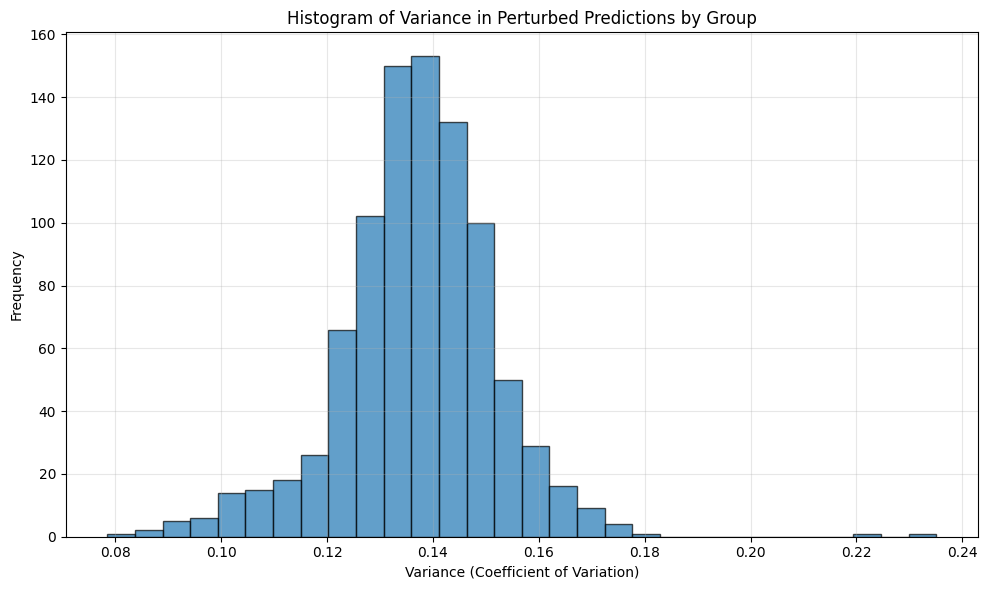

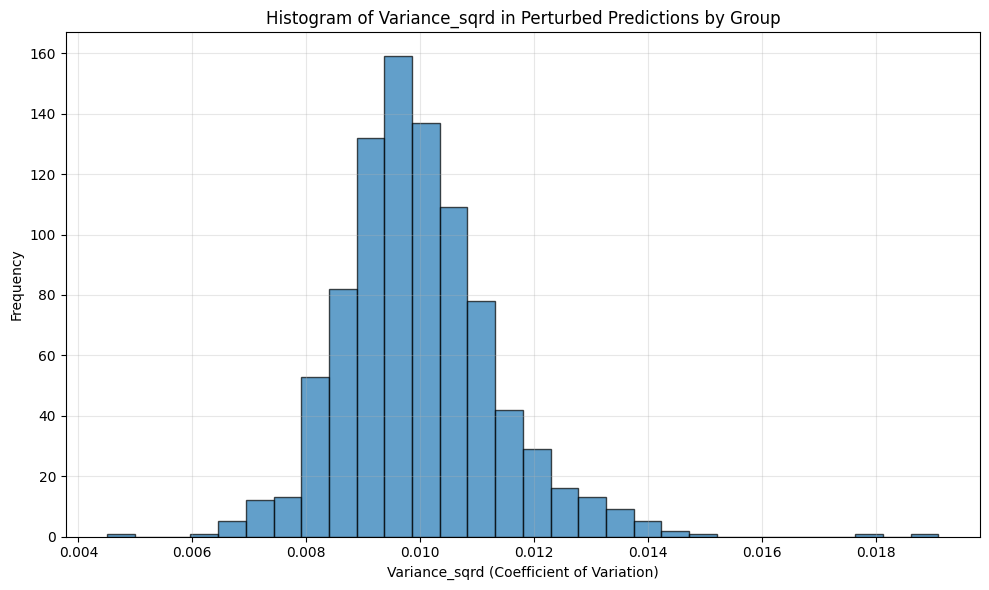

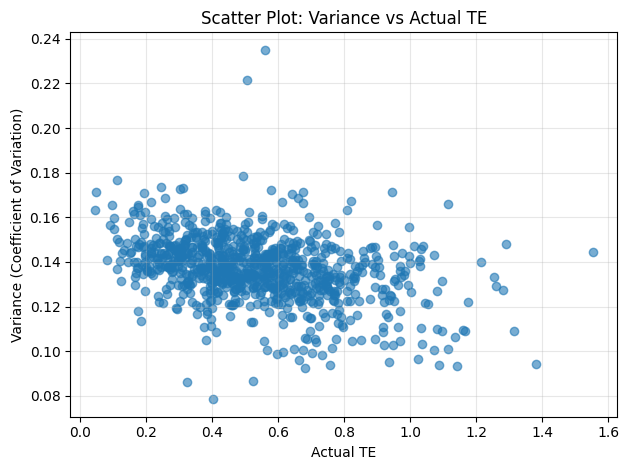

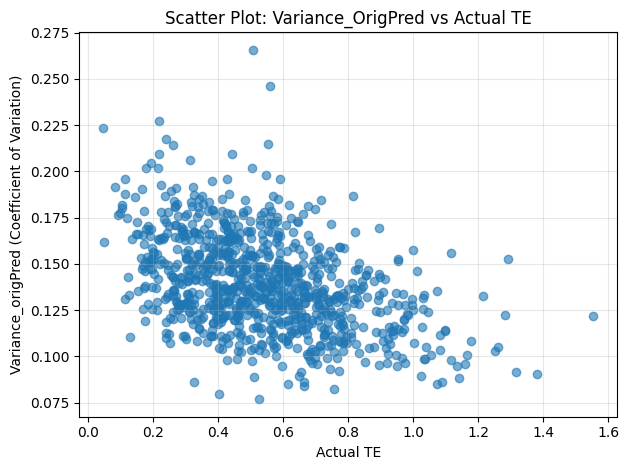

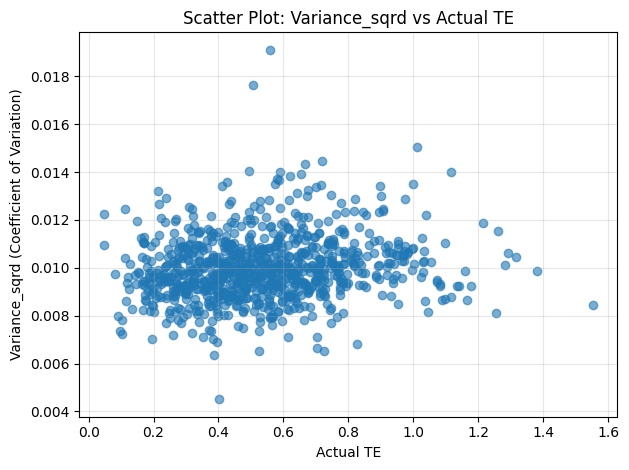

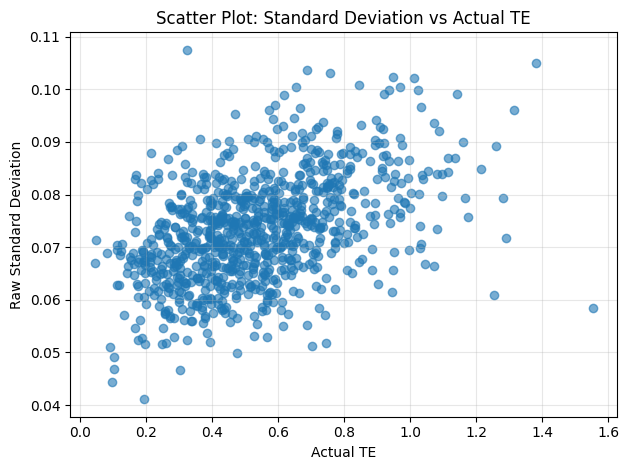

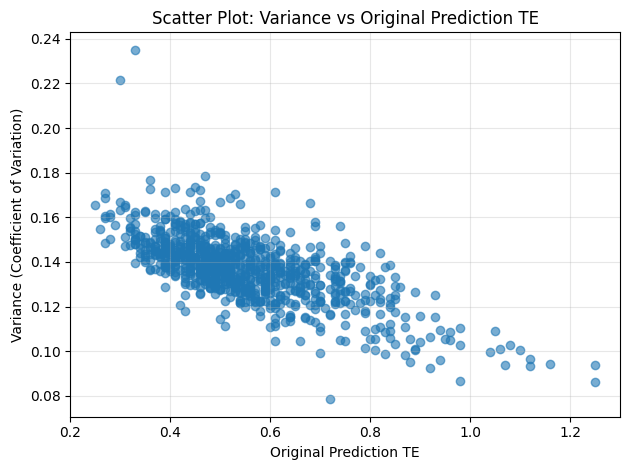

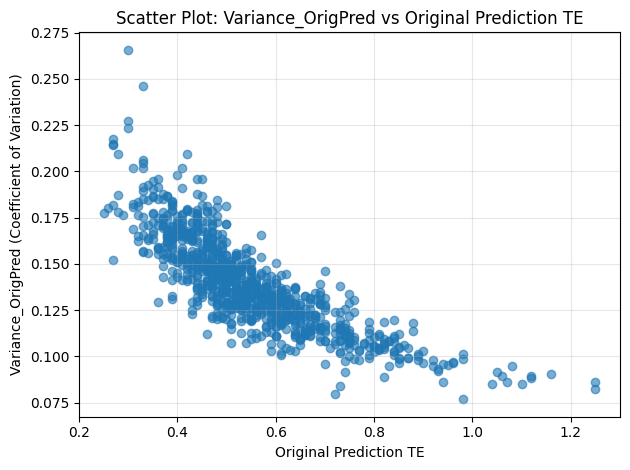

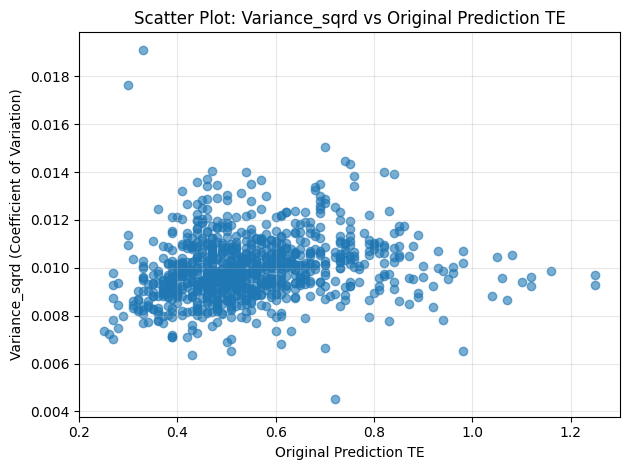

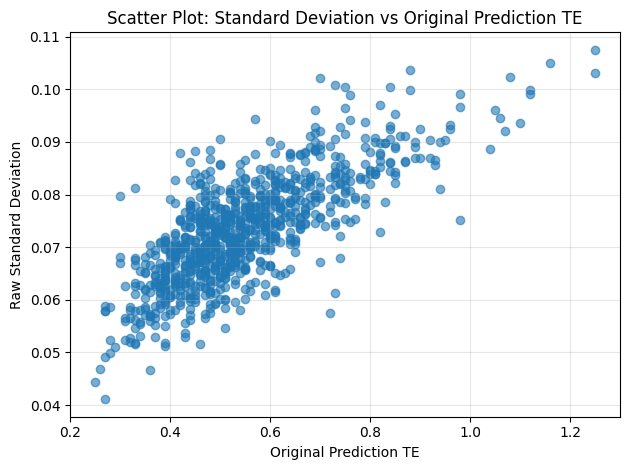

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(variance, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Variance (Coefficient of Variation)')
plt.ylabel('Frequency')
plt.title('Histogram of Variance in Perturbed Predictions by Group')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(variance_sqrd, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Variance_sqrd (Coefficient of Variation)')
plt.ylabel('Frequency')
plt.title('Histogram of Variance_sqrd in Perturbed Predictions by Group')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['actual'].groupby(seqImpact['trID']).mean(), variance, alpha=0.6)
plt.xlabel('Actual TE')
plt.ylabel('Variance (Coefficient of Variation)')
plt.title('Scatter Plot: Variance vs Actual TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['actual'].groupby(seqImpact['trID']).mean(), variance_origPred, alpha=0.6)
plt.xlabel('Actual TE')
plt.ylabel('Variance_origPred (Coefficient of Variation)')
plt.title('Scatter Plot: Variance_OrigPred vs Actual TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['actual'].groupby(seqImpact['trID']).mean(), variance_sqrd, alpha=0.6)
plt.xlabel('Actual TE')
plt.ylabel('Variance_sqrd (Coefficient of Variation)')
plt.title('Scatter Plot: Variance_sqrd vs Actual TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['actual'].groupby(seqImpact['trID']).mean(), seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std(), alpha=0.6)
plt.xlabel('Actual TE')
plt.ylabel('Raw Standard Deviation')
plt.title('Scatter Plot: Standard Deviation vs Actual TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean(), variance, alpha=0.6)
plt.xlabel('Original Prediction TE')
plt.ylabel('Variance (Coefficient of Variation)')
plt.title('Scatter Plot: Variance vs Original Prediction TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean(), variance_origPred, alpha=0.6)
plt.xlabel('Original Prediction TE')
plt.ylabel('Variance_OrigPred (Coefficient of Variation)')
plt.title('Scatter Plot: Variance_OrigPred vs Original Prediction TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean(), variance_sqrd, alpha=0.6)
plt.xlabel('Original Prediction TE')
plt.ylabel('Variance_sqrd (Coefficient of Variation)')
plt.title('Scatter Plot: Variance_sqrd vs Original Prediction TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.scatter(seqImpact['originalPrediction'].groupby(seqImpact['trID']).mean(), seqImpact['perturbedPrediction'].groupby(seqImpact['trID']).std(), alpha=0.6)
plt.xlabel('Original Prediction TE')
plt.ylabel('Raw Standard Deviation')
plt.title('Scatter Plot: Standard Deviation vs Original Prediction TE')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
vHigh = [i for i in range(len(variance)) if variance_sqrd[i] > 0.014]
vLow = [i for i in range(len(variance)) if variance_sqrd[i] < 0.007]
print(vHigh)
print(vLow)

[190, 225, 260, 276, 318, 728]
[52, 273, 432, 705, 780, 819, 843]


In [18]:
vHigh = variance_sqrd[variance_sqrd > 0.014]
vLow = variance_sqrd[variance_sqrd < 0.007]
print(vHigh)
print(vLow)

trID
FBtr0075184    0.014321
FBtr0075954    0.015031
FBtr0077084    0.019104
FBtr0077520    0.014479
FBtr0079000    0.014063
FBtr0300488    0.017646
Name: perturbedPrediction, dtype: float64
trID
FBtr0071402    0.006654
FBtr0077478    0.006799
FBtr0082239    0.006884
FBtr0113748    0.006339
FBtr0305141    0.004509
FBtr0332406    0.006514
FBtr0334627    0.006511
Name: perturbedPrediction, dtype: float64


In [19]:
for r in vHigh.items():
    print(r)

('FBtr0075184', 0.01432054457734806)
('FBtr0075954', 0.01503114475605758)
('FBtr0077084', 0.019104114976206954)
('FBtr0077520', 0.01447930722609755)
('FBtr0079000', 0.01406295727706605)
('FBtr0300488', 0.017645855387469614)


[29, 212, 318, 514, 796]


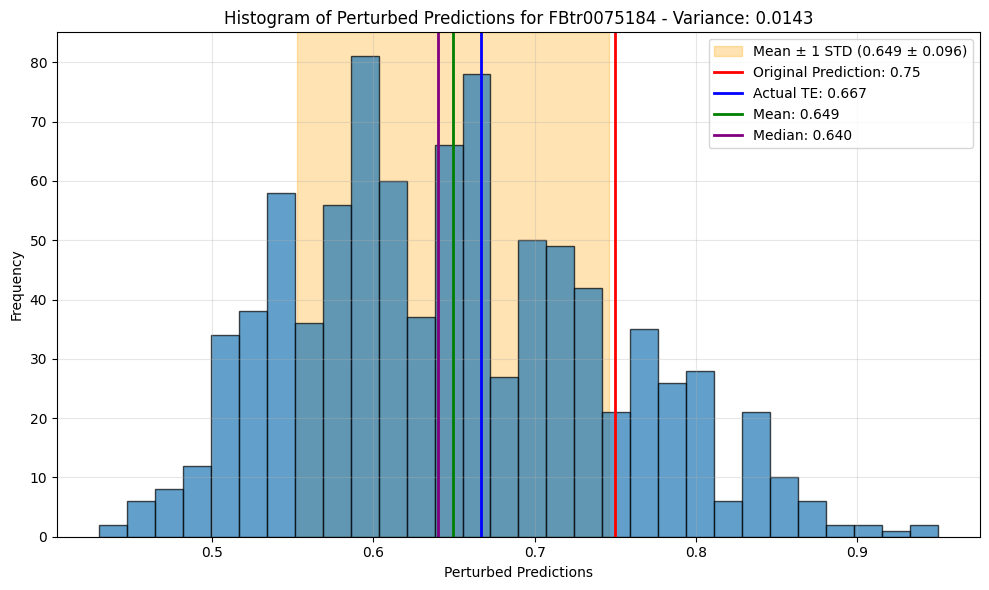

[4, 210, 319, 515, 798]


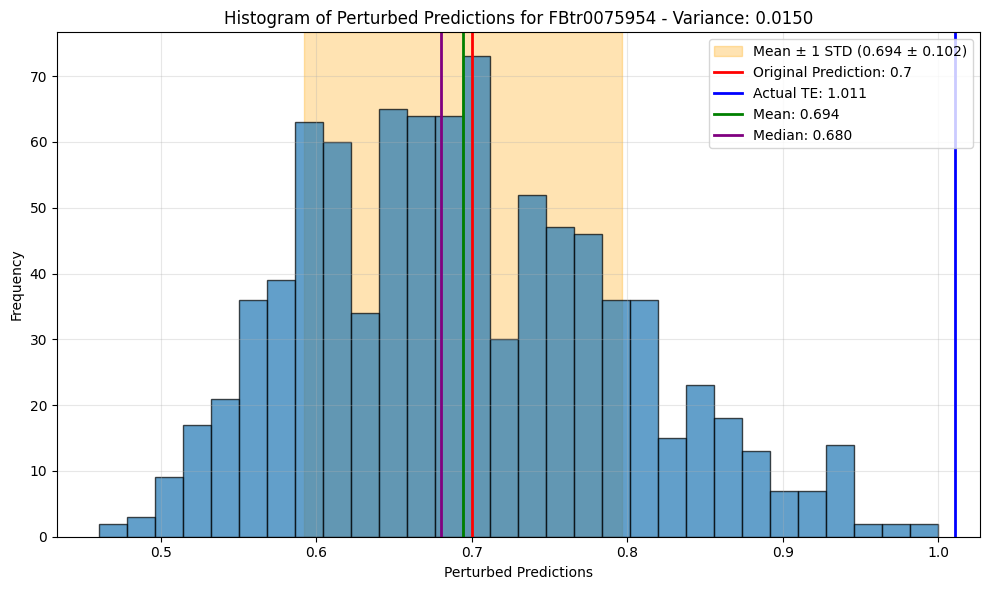

[39, 193, 271, 442, 503]


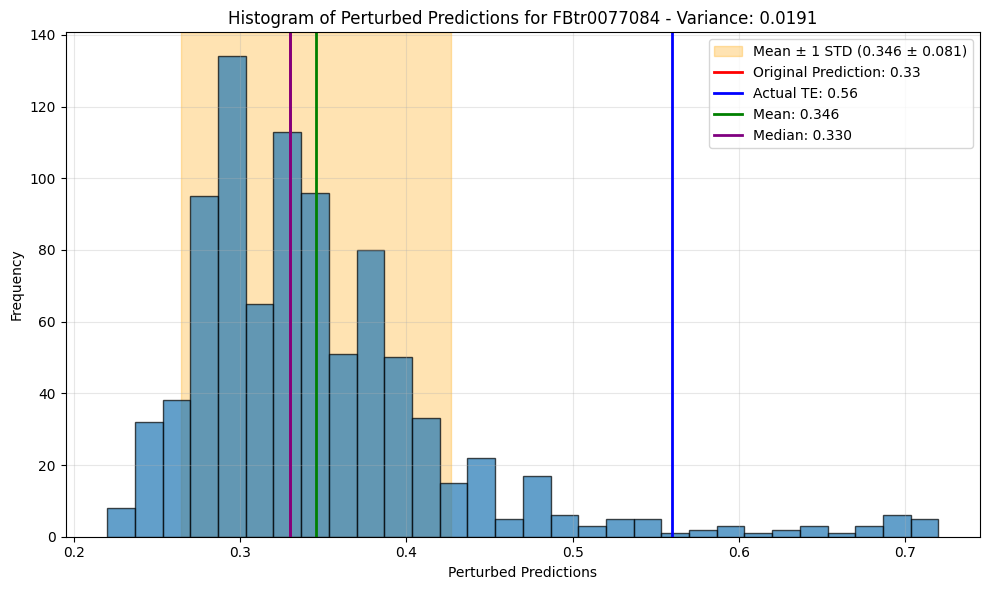

[101, 382, 579, 688, 872]


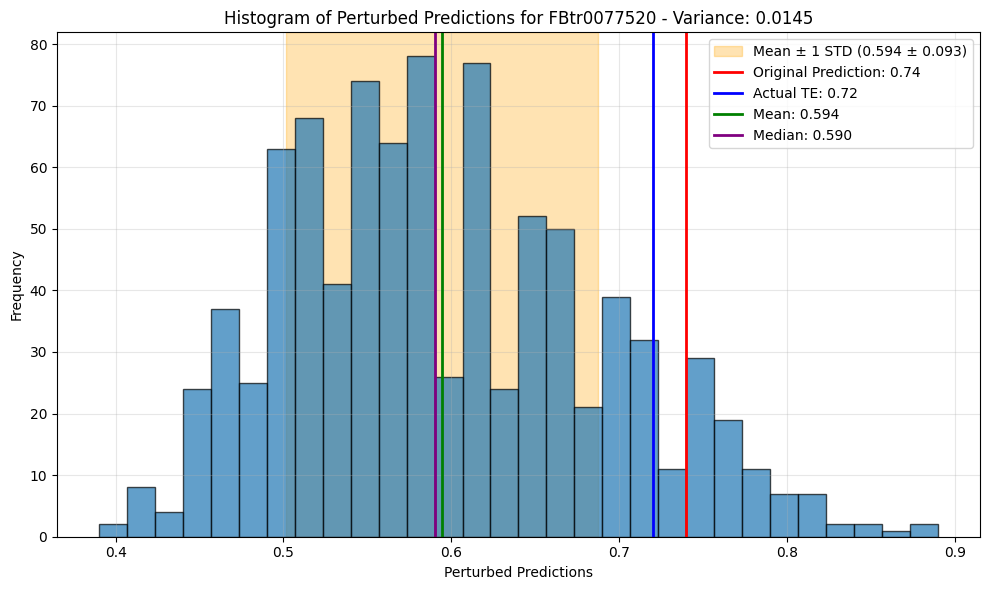

[101, 206, 382, 577, 686, 897]


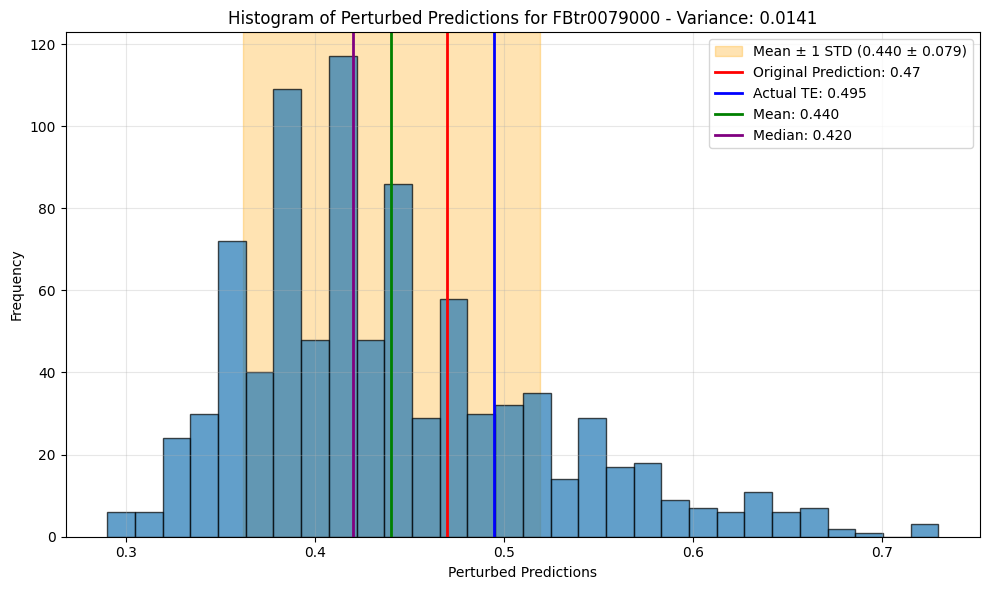

[34, 187, 267, 437, 498]


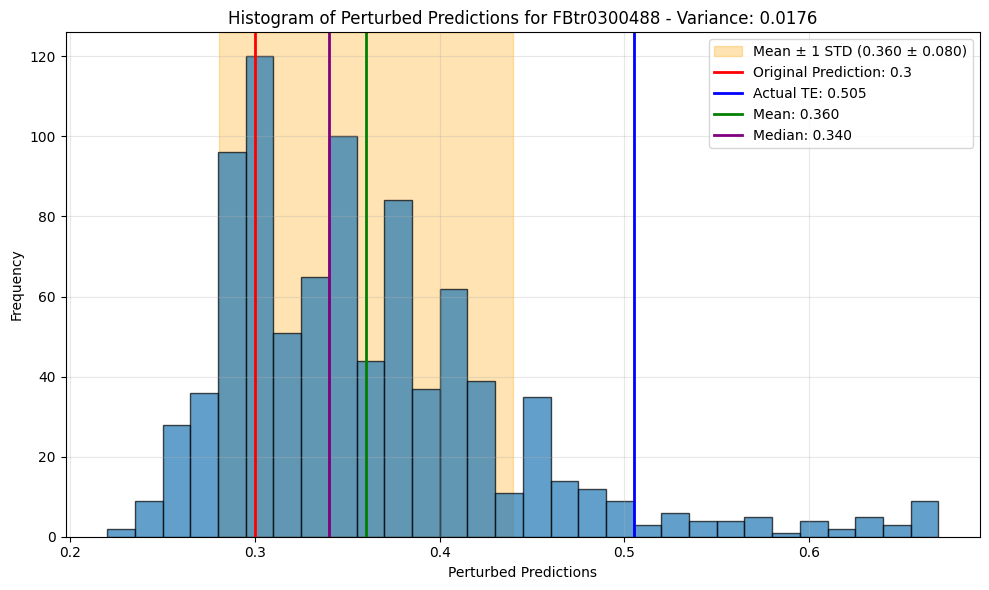

In [20]:
for r in vHigh.items():
    plt.figure(figsize=(10, 6))
    group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == r[0]]
    sorted = group_0_predictions.sort_values(ascending=False).values
    highPreds = [j for j in range(len(group_0_predictions)) if group_0_predictions.values[j] in sorted[:5]]
    print(highPreds)
    original_prediction = seqImpact[seqImpact['trID'] == r[0]]['originalPrediction'].values[0]
    actualTE = seqImpact['actual'][seqImpact['trID'] == r[0]].values[0]
    mean_val = group_0_predictions.mean()
    std_val = group_0_predictions.std()
    plt.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.3, color='orange', label=f'Mean ± 1 STD ({mean_val:.3f} ± {std_val:.3f})')
    plt.hist(group_0_predictions, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
    plt.axvline(x=actualTE, color='blue', linestyle='-', linewidth=2, label=f'Actual TE: {actualTE}')
    plt.axvline(x=mean_val, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.3f}')
    plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
    plt.xlabel('Perturbed Predictions')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Perturbed Predictions for {r[0]} - Variance: {r[1]:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

[108, 388, 580, 688, 721]


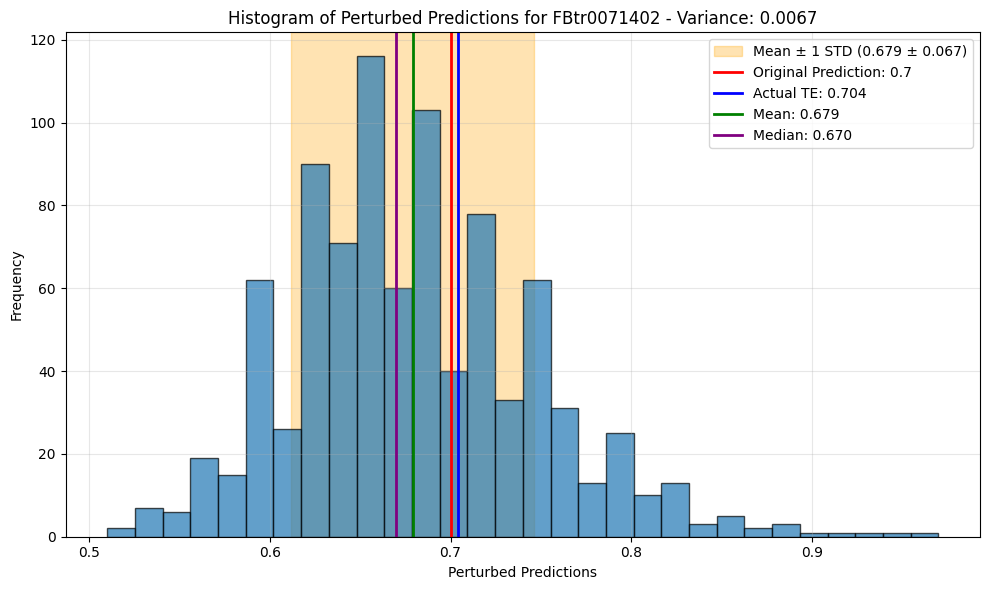

[103, 383, 579, 687, 720]


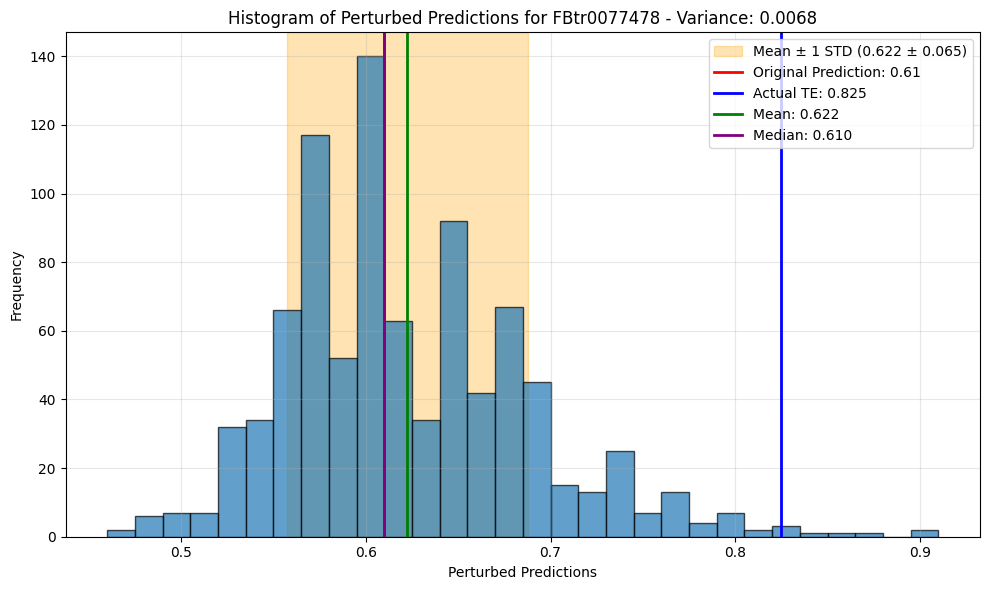

[102, 383, 578, 687, 720]


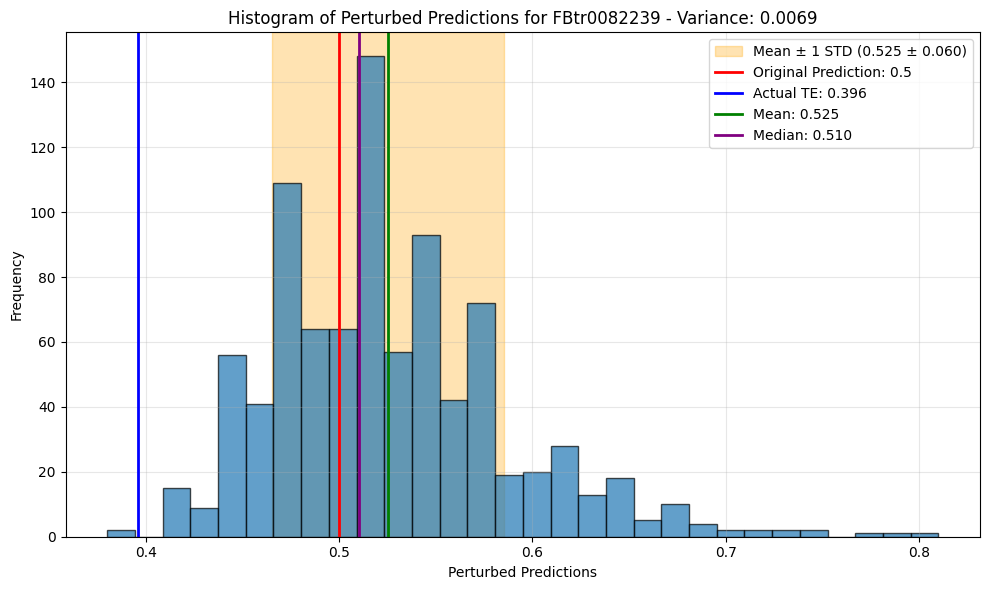

[108, 388, 580, 689, 722]


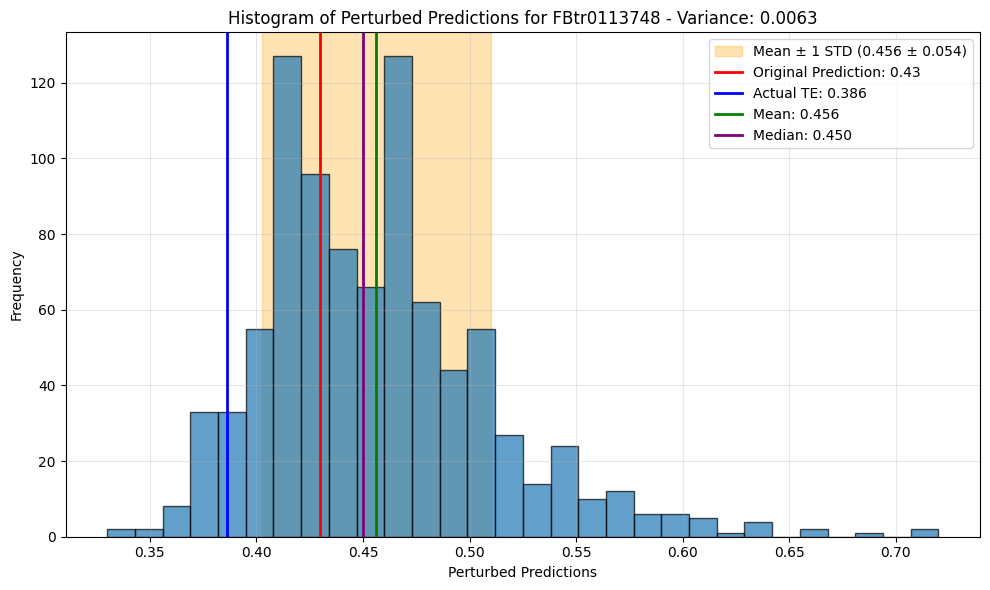

[42, 102, 382, 687, 719]


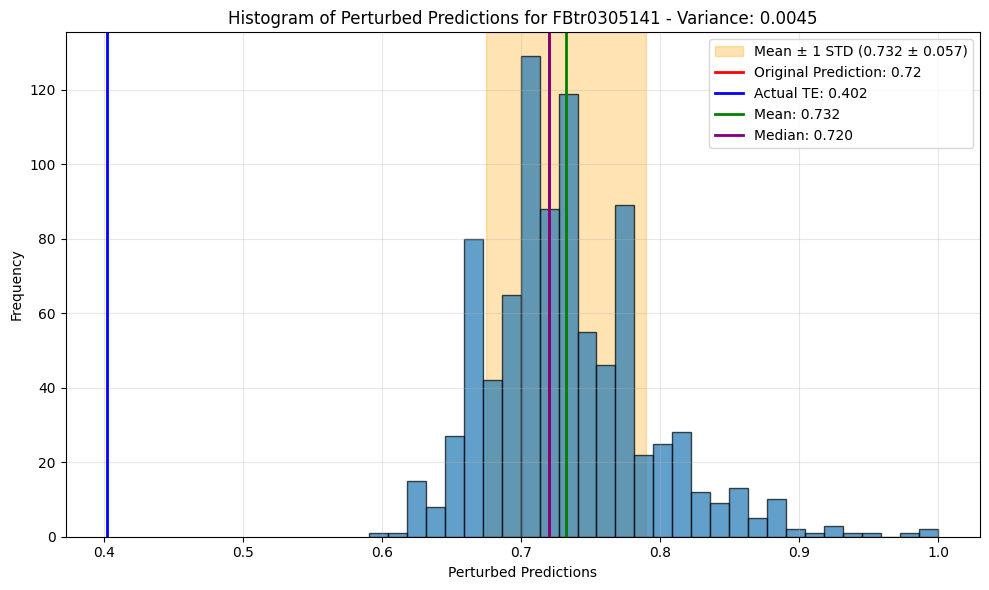

[45, 104, 380, 386, 581, 701, 722, 884]


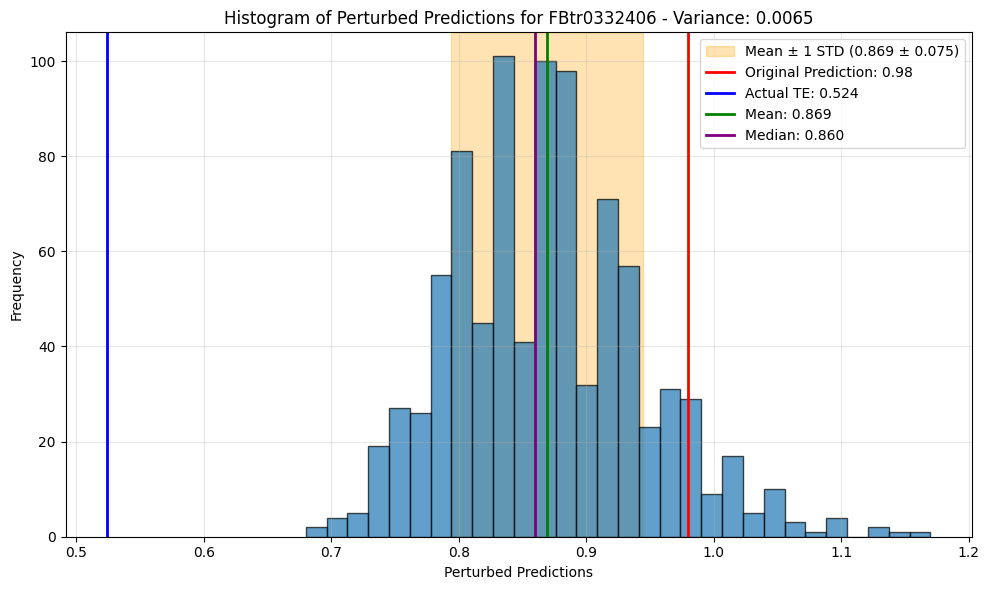

[174, 208, 318, 515, 796]


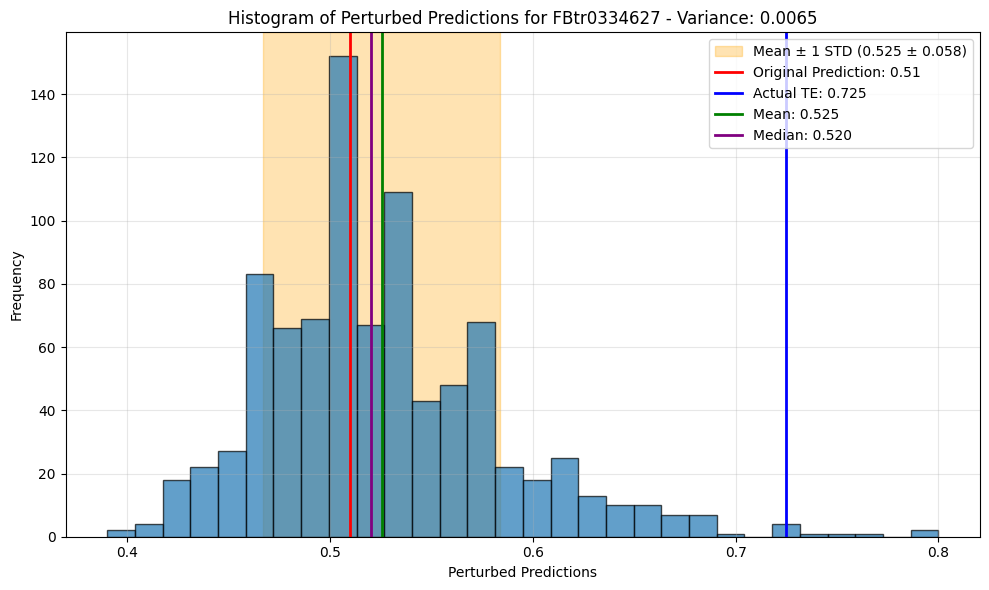

In [21]:
for r in vLow.items():
    plt.figure(figsize=(10, 6))
    group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == r[0]]
    sorted = group_0_predictions.sort_values(ascending=False).values
    highPreds = [j for j in range(len(group_0_predictions)) if group_0_predictions.values[j] in sorted[:5]]
    print(highPreds)
    original_prediction = seqImpact[seqImpact['trID'] == r[0]]['originalPrediction'].values[0]
    actualTE = seqImpact['actual'][seqImpact['trID'] == r[0]].values[0]
    mean_val = group_0_predictions.mean()
    std_val = group_0_predictions.std()
    plt.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.3, color='orange', label=f'Mean ± 1 STD ({mean_val:.3f} ± {std_val:.3f})')
    plt.hist(group_0_predictions, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
    plt.axvline(x=actualTE, color='blue', linestyle='-', linewidth=2, label=f'Actual TE: {actualTE}')
    plt.axvline(x=mean_val, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.3f}')
    plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
    plt.xlabel('Perturbed Predictions')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Perturbed Predictions for {r[0]} - Variance: {r[1]:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# look at the distribution of the seq shuffle and the extraFeatures shuffle for the same seq

In [22]:
print(seqImpact['trID'].values[-1])
print(seqImpact['trID'][:11])

FBtr0479891
787500    FBtr0070007
787806    FBtr0070007
787805    FBtr0070007
787804    FBtr0070007
787803    FBtr0070007
787802    FBtr0070007
787801    FBtr0070007
787800    FBtr0070007
787799    FBtr0070007
787798    FBtr0070007
787797    FBtr0070007
Name: trID, dtype: object


In [24]:
seqImpact.iloc[0,:]

trID                   FBtr0070007
actual                       0.259
originalPrediction             0.4
perturbedPrediction           0.28
sequenceCount               787501
Name: 787500, dtype: object

In [26]:
seqImpact.head()

,trID,actual,originalPrediction,perturbedPrediction,sequenceCount
787500,FBtr0070007,0.259,0.4,0.28,787501
787806,FBtr0070007,0.259,0.4,0.33,787807
787805,FBtr0070007,0.259,0.4,0.32,787806
787804,FBtr0070007,0.259,0.4,0.38,787805
787803,FBtr0070007,0.259,0.4,0.29,787804


In [27]:
extraFeatImpact.head()

,trID,actual,originalPrediction,perturbedPrediction,sequenceCount
0,FBtr0085759,0.845,0.73,0.51,1
1,FBtr0083713,0.845,0.73,0.42,2
2,FBtr0084377,0.845,0.73,0.39,3
3,FBtr0335206,0.845,0.73,0.34,4
4,FBtr0085452,0.845,0.73,0.44,5


In [25]:
eGroups_fixed[0]

'0.845_0.73_0'

0.259_0.4_0


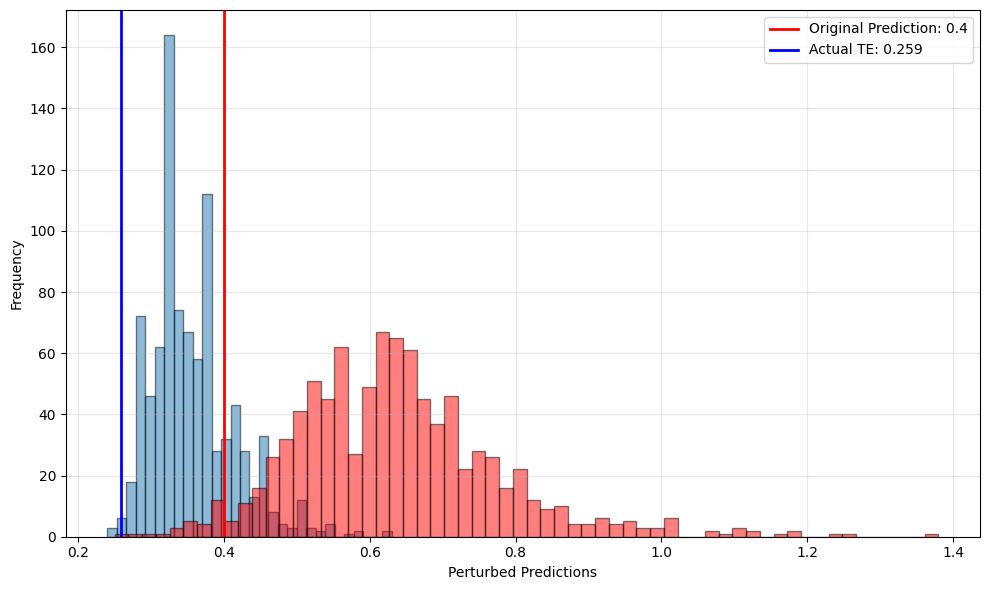

1.282_0.65_0


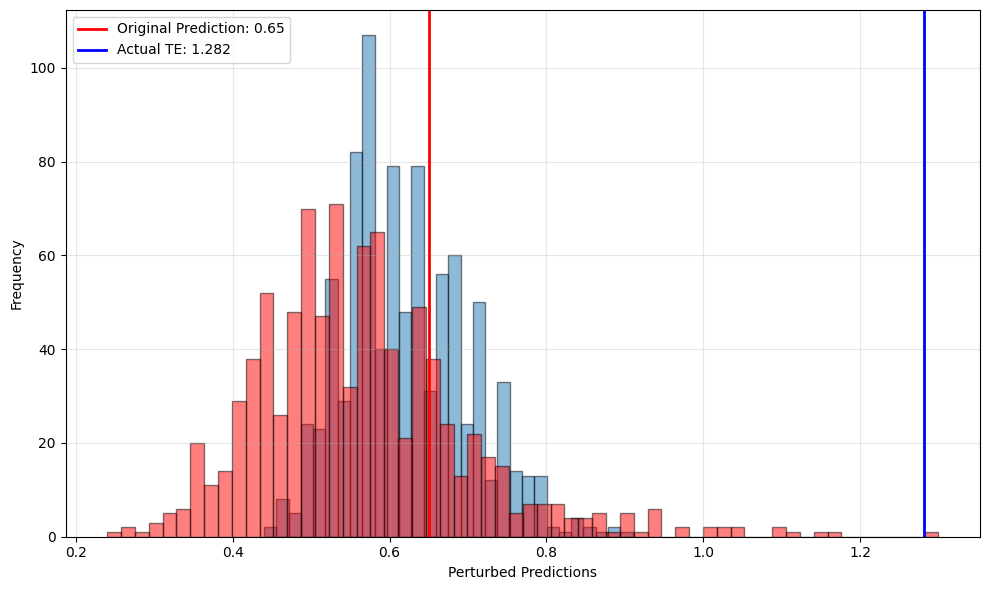

In [32]:
for i in [0,-1]:
    plt.figure(figsize=(10, 6))
    group_0_predictions = seqImpact['perturbedPrediction'][seqImpact['trID'] == seqImpact['trID'].values[i]]
    actual_val = seqImpact['actual'].values[i]
    orig_pred_val = seqImpact['originalPrediction'].values[i]
    eG = f'{actual_val}_{orig_pred_val}_0'
    print(eG)
    group_0_predictions_e = extraFeatImpact['perturbedPrediction'][pd.Series(eGroups_fixed) == eG]
    #group_0_predictions_e = extraFeatImpact['perturbedPrediction'][e == eGroups_fixed[0] for e in eGroups_fixed]
    original_prediction = seqImpact[seqImpact['trID'] == seqImpact['trID'].values[i]]['originalPrediction'].values[i]
    actualTE = seqImpact['actual'][seqImpact['trID'] == seqImpact['trID'].values[i]].values[i]
    mean_val = group_0_predictions.mean()
    std_val = group_0_predictions.std()
    #plt.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.3, color='orange', label=f'Mean ± 1 STD ({mean_val:.3f} ± {std_val:.3f})')
    plt.hist(group_0_predictions, bins=30, alpha=0.5, edgecolor='black')
    plt.hist(group_0_predictions_e, bins=60, alpha=0.5, edgecolor='black',color='red')
    plt.axvline(x=original_prediction, color='red', linestyle='-', linewidth=2, label=f'Original Prediction: {original_prediction}')
    plt.axvline(x=actualTE, color='blue', linestyle='-', linewidth=2, label=f'Actual TE: {actualTE}')
    #plt.axvline(x=mean_val, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.3f}')
    #plt.axvline(x=group_0_predictions.median(), color='purple', linestyle='-', linewidth=2, label=f'Median: {group_0_predictions.median():.3f}')
    plt.xlabel('Perturbed Predictions')
    plt.ylabel('Frequency')
    #plt.title(f'Histogram of PerturbeId Predictions for {r[0]} - Variance: {r[1]:.4f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
seqImpact[seqImpact['trID'] == 'FBtr0079000'][['trID','actual','originalPrediction']].drop_duplicates()

,trID,actual,originalPrediction
801901,FBtr0079000,0.495,0.47


In [35]:
x = 4074
print(importance[x].id,importance[x].actual,importance[x].prediction)
x = 1821
print(importance[x].id,importance[x].actual,importance[x].prediction)

FBtr0077243 1.52 0.99
FBtr0076808 1.9 1.56


In [101]:
# import tqdm
# groupDiff = []
# diffsByGroup = []
# count = 0 #4212 total sequences
# #prevVal = seqImpact['originalPrediction'][0]
# for row in tqdm.tqdm(seqImpact.iterrows(), total=seqImpact.shape[0], desc="Calculating differences"):
#     if count % 4212 == 0 and count > 0:
#     #if row[1]['originalPrediction'] != prevVal:
#         diffsByGroup.append(groupDiff)
#         groupDiff = []
#     groupDiff.append(row[1]['originalPrediction'] - row[1]['perturbedPrediction'])
#     #prevVal = row[1]['originalPrediction']
#     count += 1
# 

# Create group identifiers (0, 1, 2, ...) for every 4212 rows
group_ids = seqImpact.index // 4212

# Calculate differences vectorized with normalization by group statistics
differences = np.abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction'])

# Standardize each group by their respective mean and std
differences = (differences - differences.groupby(group_ids).transform('mean')) / differences.groupby(group_ids).transform('std')

# Group standardized differences by group_id and convert to list
diffsByGroup = [group.values for _, group in differences.groupby(group_ids)]

differences_actual = np.abs(seqImpact['actual'] - seqImpact['perturbedPrediction'])
differences_actual = (differences_actual - differences_actual.groupby(group_ids).transform('mean')) / differences_actual.groupby(group_ids).transform('std')
diffsByGroup_actual = [group.values for _, group in differences_actual.groupby(group_ids)]

In [102]:
dBG = [np.mean(np.abs(group)) for group in diffsByGroup]
dBG_actual = [np.mean(np.abs(group)) for group in diffsByGroup_actual]
print(np.mean(dBG))
print(np.mean(dBG_actual))

0.7171662219430048
0.7433991567879867


In [103]:
print(len(diffsByGroup))
print(np.unique([len(g) for g in diffsByGroup]))

4213
[4212]


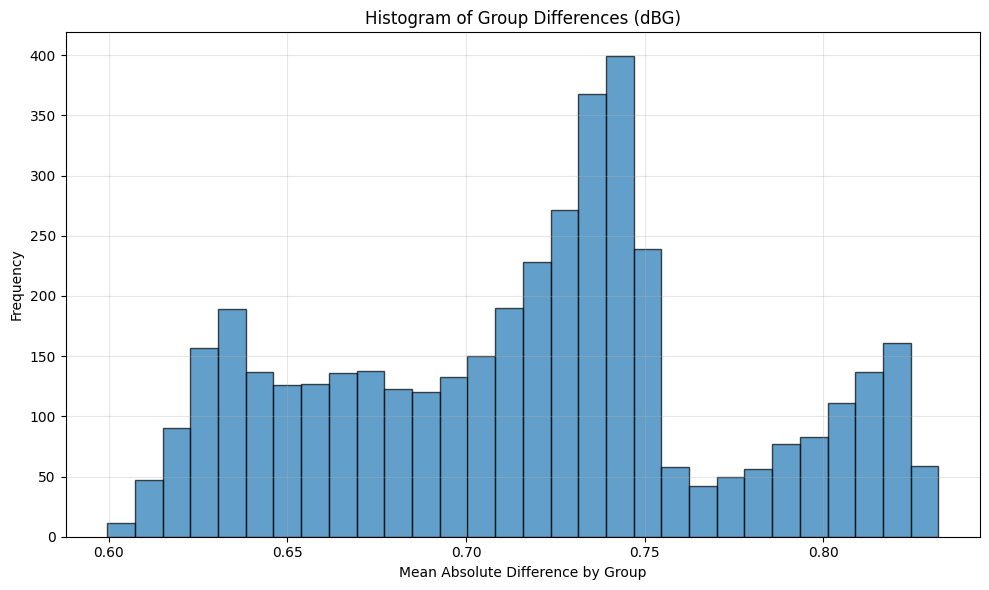

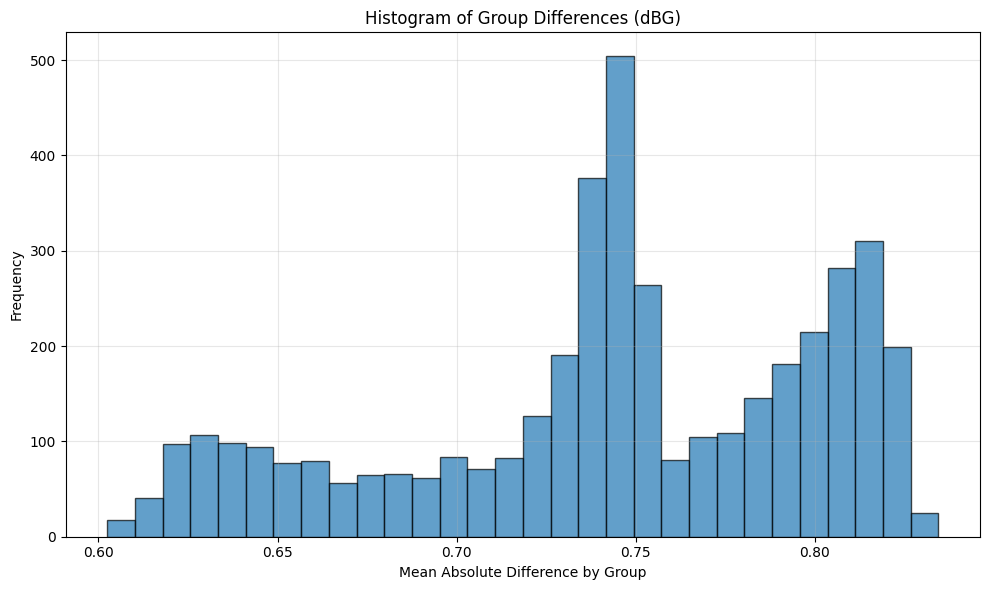

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(dBG, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Absolute Difference by Group')
plt.ylabel('Frequency')
plt.title('Histogram of Group Differences (dBG)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(dBG_actual, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Absolute Difference by Group')
plt.ylabel('Frequency')
plt.title('Histogram of Group Differences (dBG)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#print([i for i in range(len(dBG)) if dBG[i] > 0.4])
print([i for i in range(len(dBG)) if dBG[i] > 0.8])
print(dBG[1])

[1, 3, 27, 80, 304, 332, 436, 452, 530, 602, 620, 746, 788, 828, 908, 1039, 1073, 1101, 1105, 1201, 1233, 1354, 1396, 1532, 1630, 1678, 1821, 1923, 2101, 2133, 2197, 2200, 2424, 2483, 2492, 2493, 2855, 2859, 3161, 3195, 3219, 3500, 3504, 3513, 3611, 3615, 3619, 3942, 4074]
[1039, 1821]
0.44349551191953285


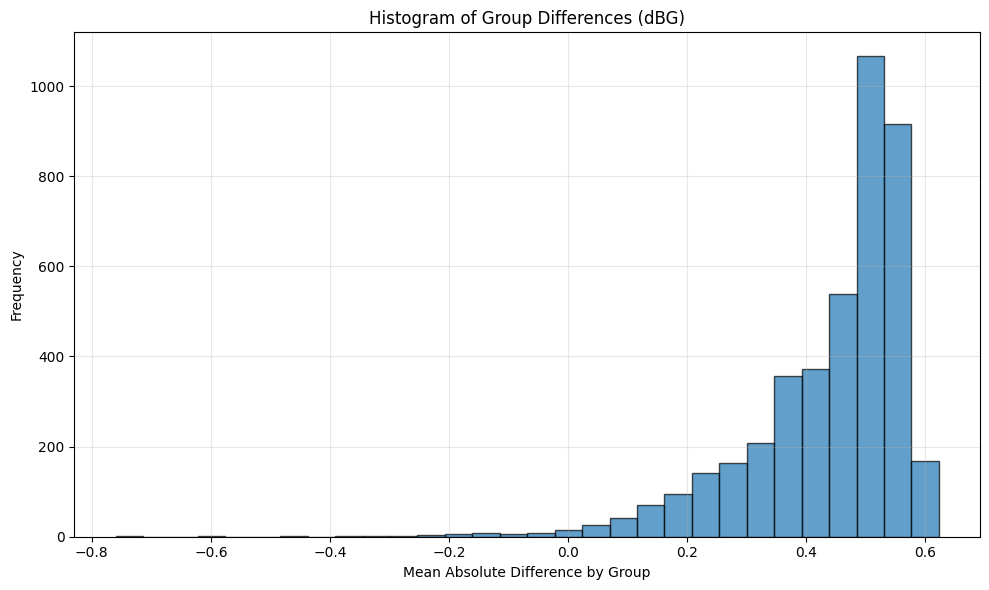

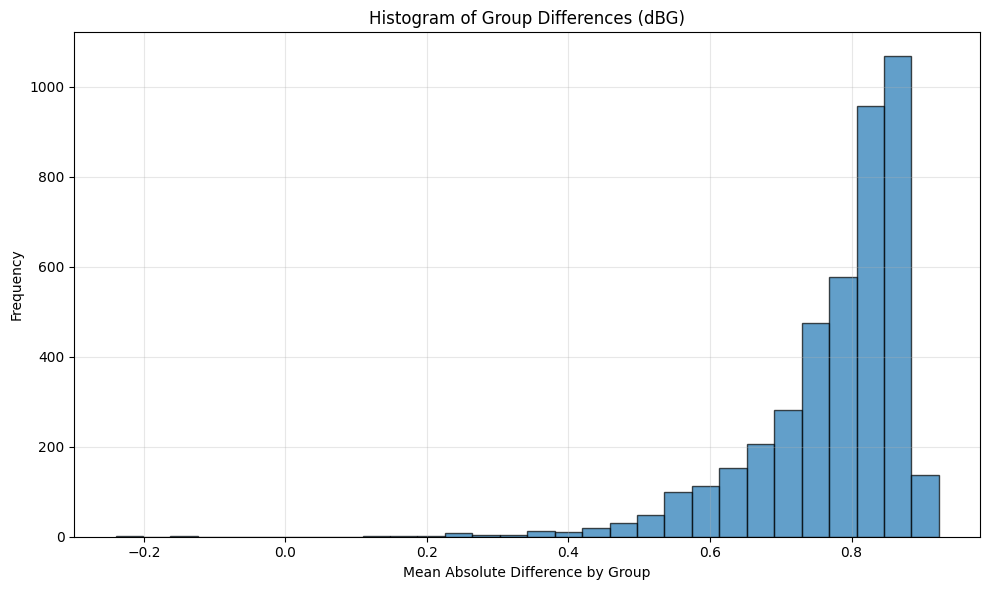

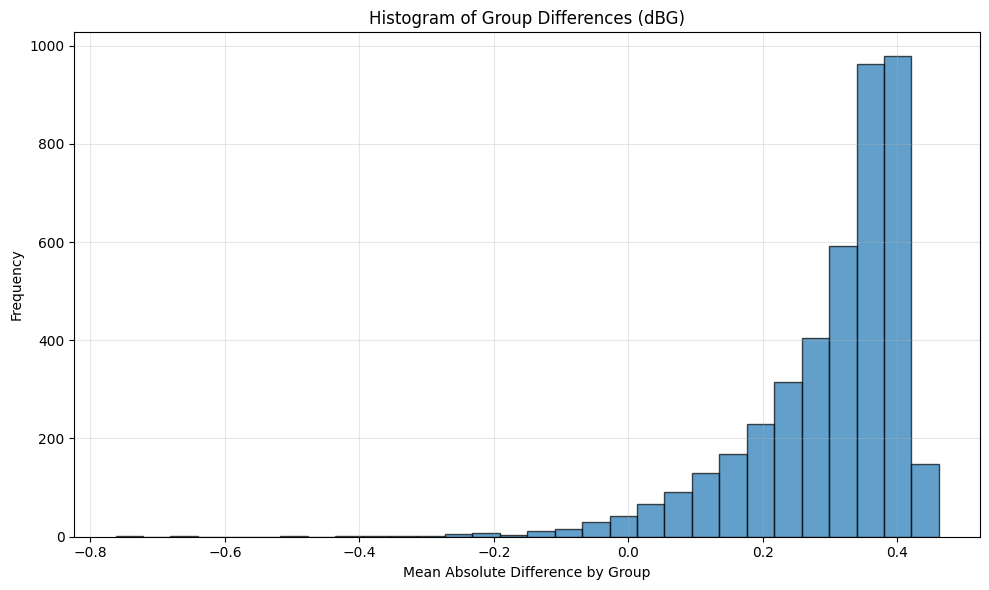

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(diffsByGroup[1], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Absolute Difference by Group')
plt.ylabel('Frequency')
plt.title('Histogram of Group Differences (dBG)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(diffsByGroup[746], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Absolute Difference by Group')
plt.ylabel('Frequency')
plt.title('Histogram of Group Differences (dBG)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(diffsByGroup[2991], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Mean Absolute Difference by Group')
plt.ylabel('Frequency')
plt.title('Histogram of Group Differences (dBG)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [91]:
print(dBG[:4])
print(np.mean(np.abs(diffsByGroup[1])))
print(np.mean(np.abs(diffsByGroup[746])))

[0.11891225809077766, 0.44349551191953285, 0.20557143686323534, 0.4218606640246506]
0.44349551191953285
0.7760204609311974


(1.3, 1.1)


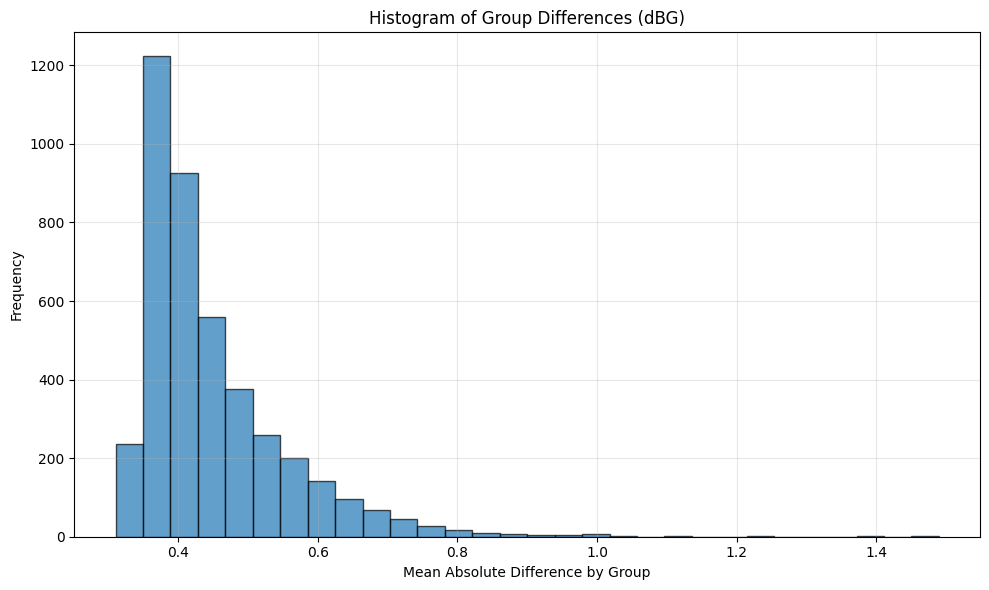

(1.7, 0.98)


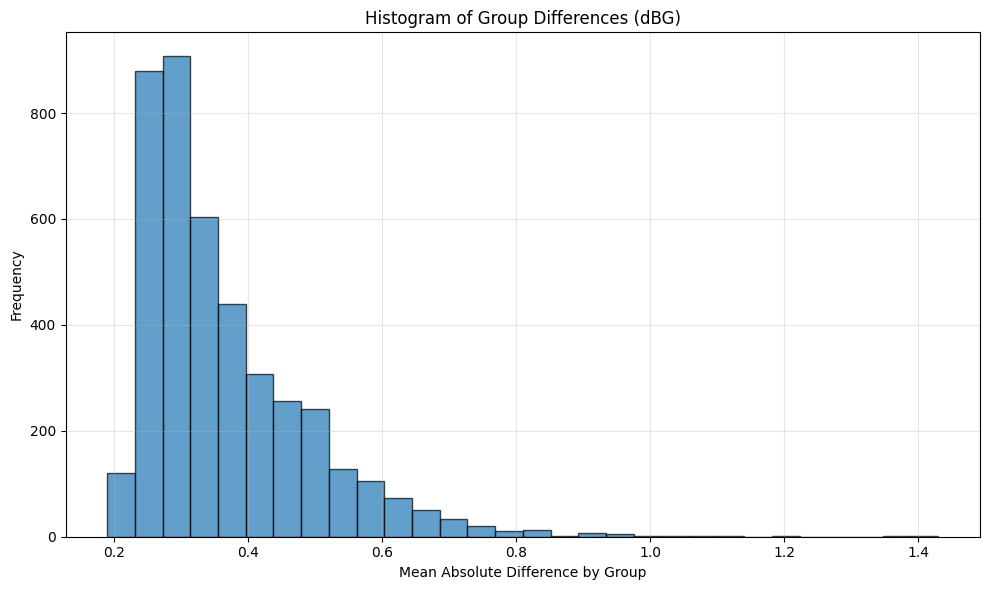

(1.35, 1.27)


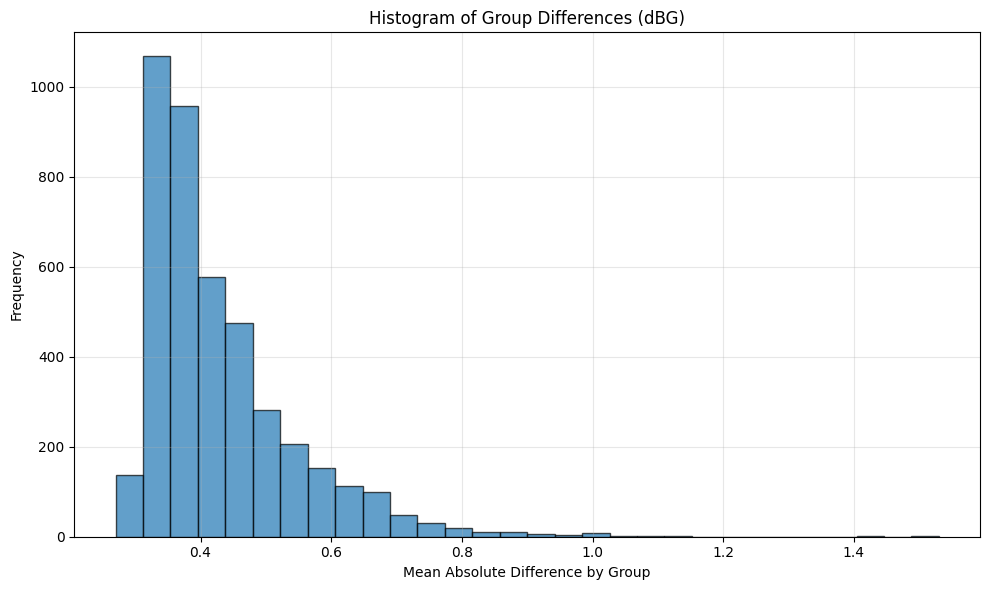

(1.61, 1.58)


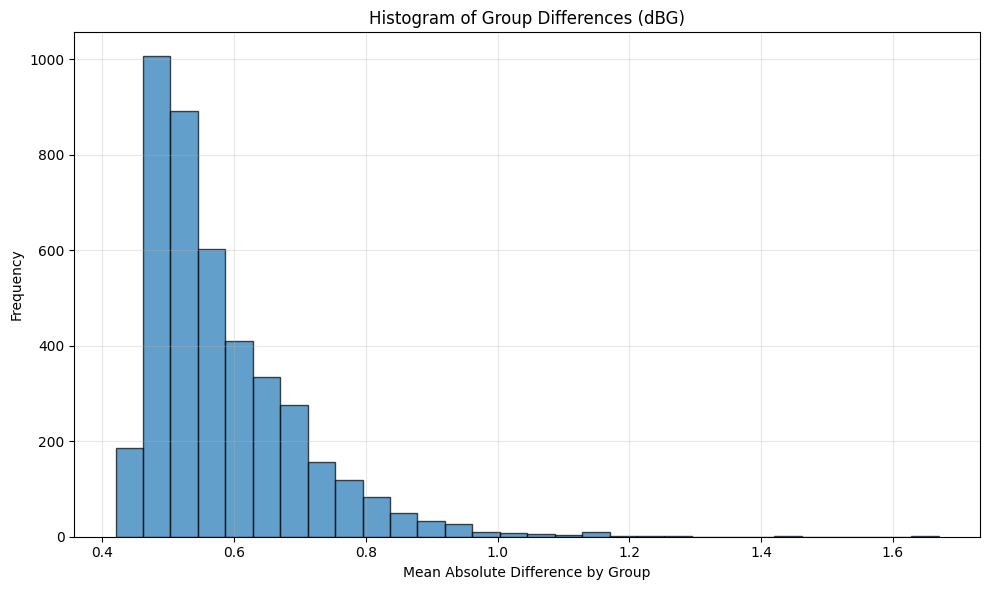

(1.06, 1.01)


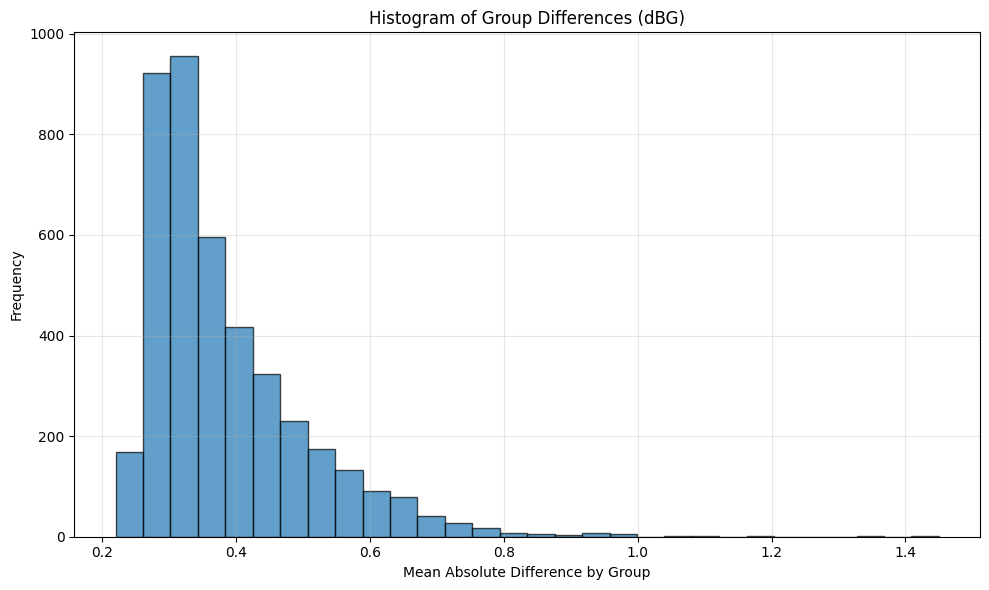

(1.9, 1.56)


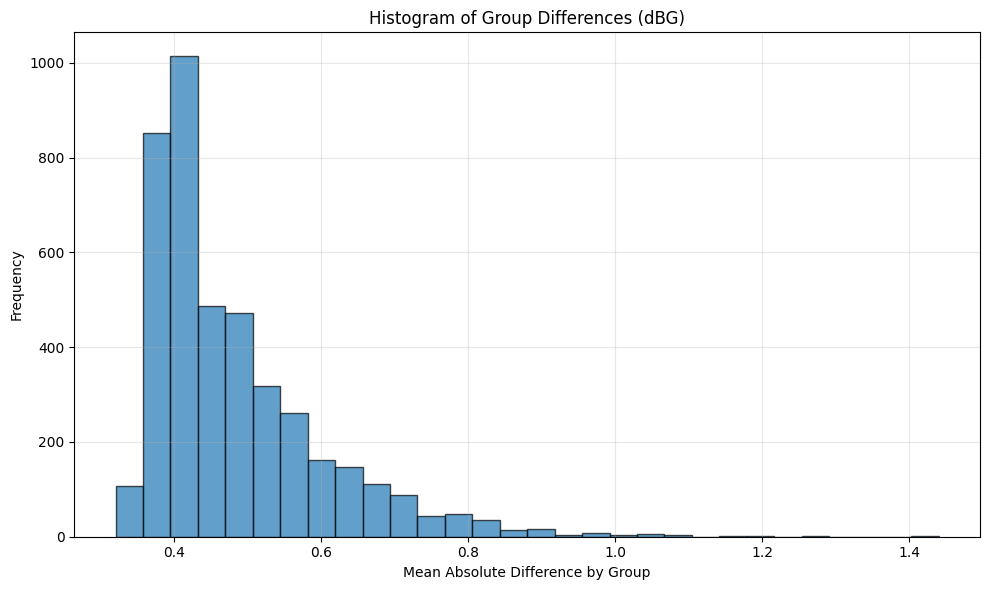

(1.52, 1.32)


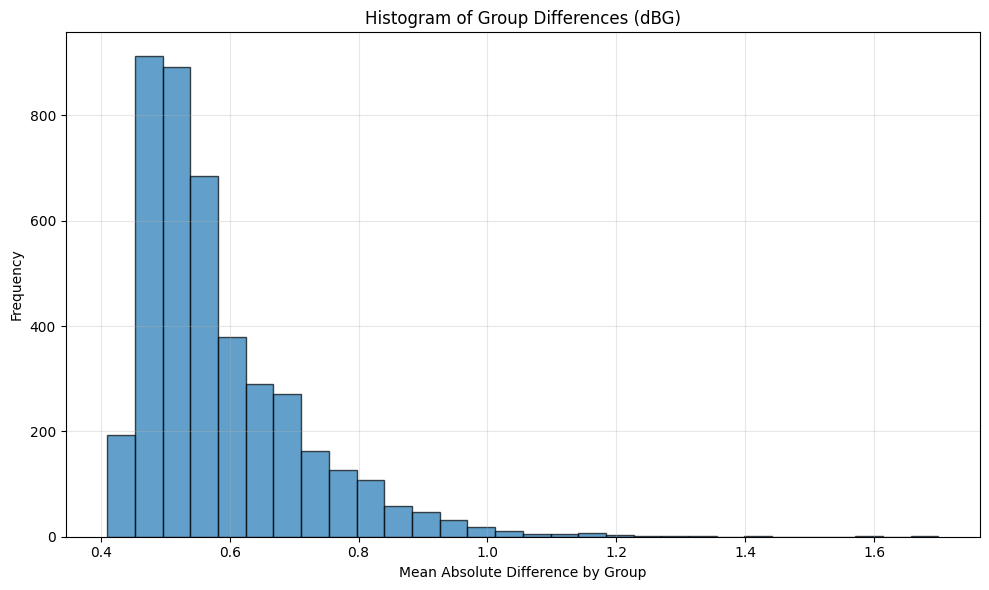

(1.52, 0.99)


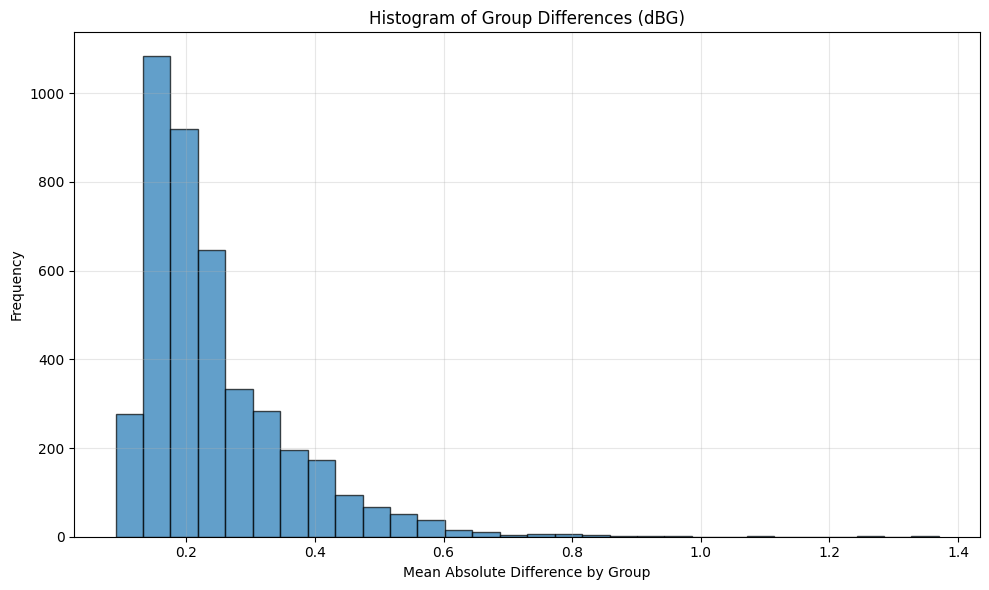

In [92]:
for outlier in [i for i in range(len(dBG)) if dBG[i] > 0.6]:
    print(actual_pred[outlier])
    plt.figure(figsize=(10, 6))
    plt.hist(seqImpact['perturbedPrediction'][outlier*4212:(outlier+1)*4212], bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Mean Absolute Difference by Group')
    plt.ylabel('Frequency')
    plt.title('Histogram of Group Differences (dBG)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [24]:
print(seqImpact['originalPrediction'][0])
print(seqImpact['originalPrediction'][1*4212])

0.36
0.85


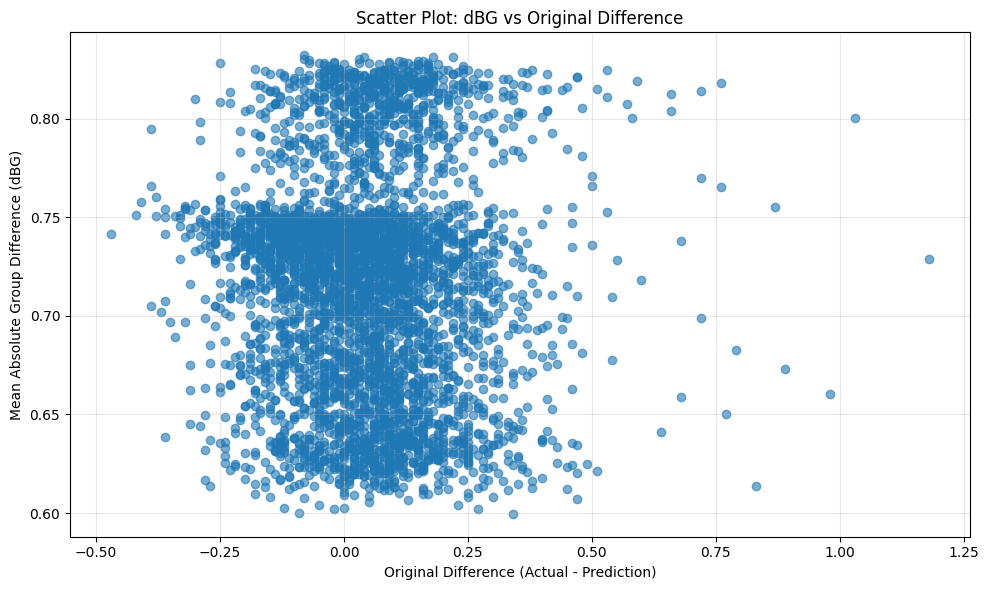

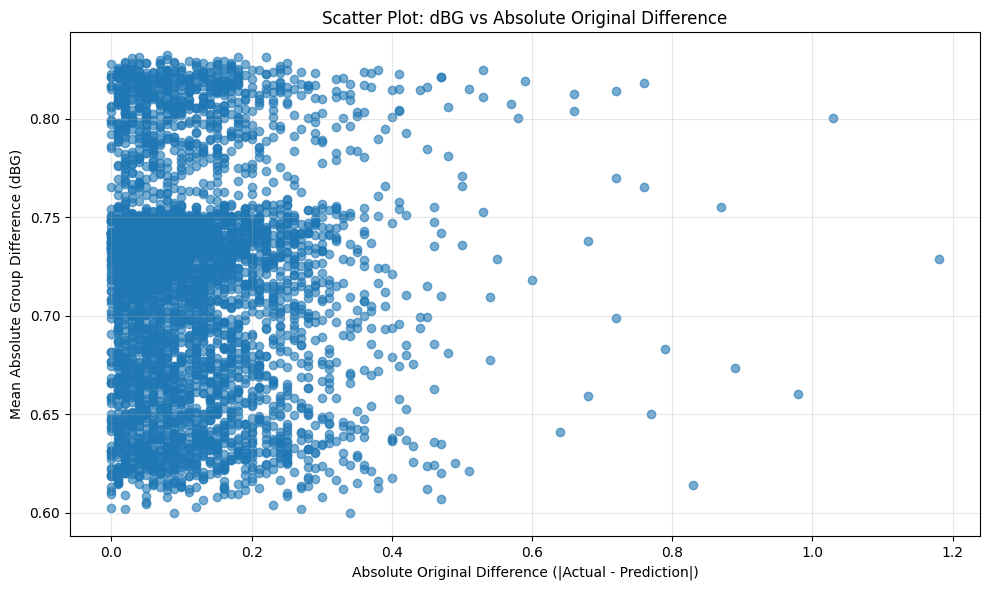

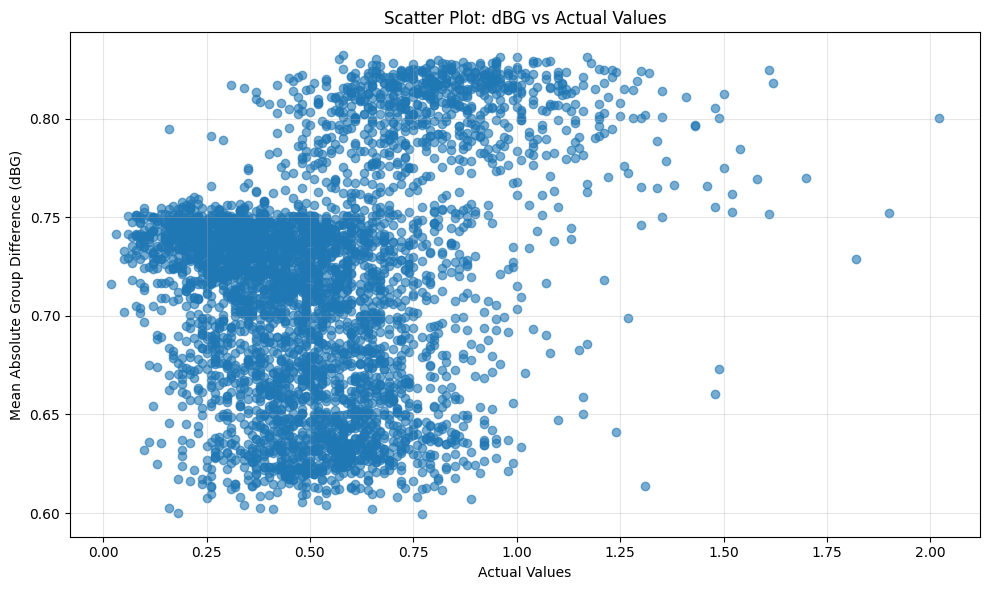

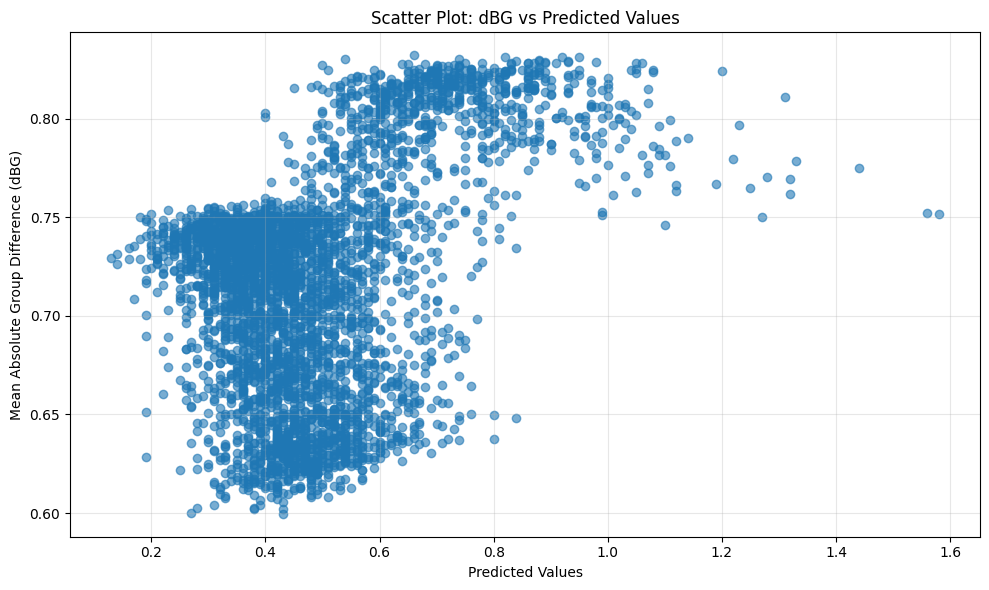

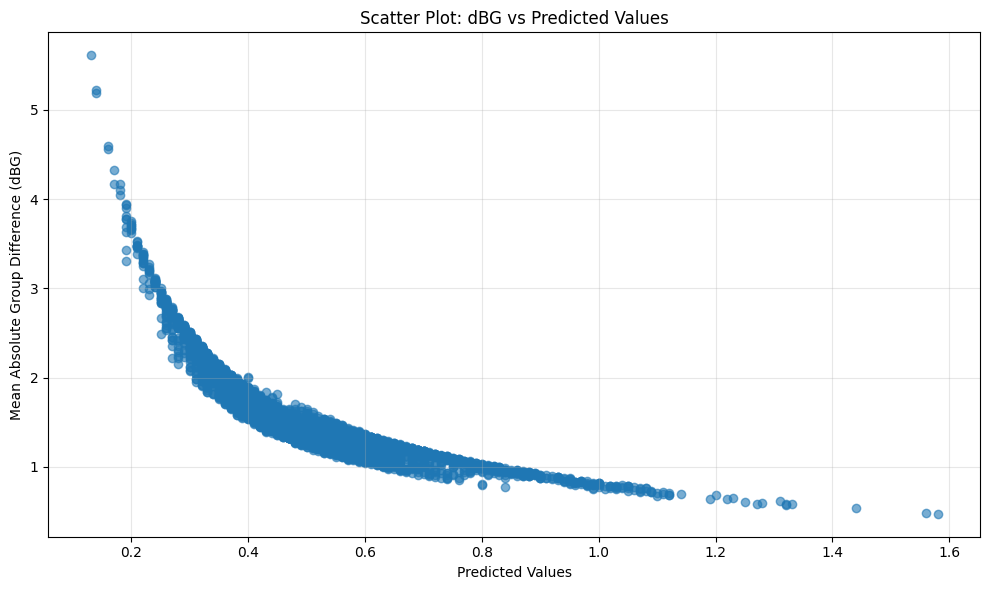

In [105]:
plt.figure(figsize=(10, 6))
plt.scatter(originalDiff, dBG, alpha=0.6)
plt.xlabel('Original Difference (Actual - Prediction)')
plt.ylabel('Mean Absolute Group Difference (dBG)')
plt.title('Scatter Plot: dBG vs Original Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(np.abs(originalDiff), dBG, alpha=0.6)
plt.xlabel('Absolute Original Difference (|Actual - Prediction|)')
plt.ylabel('Mean Absolute Group Difference (dBG)')
plt.title('Scatter Plot: dBG vs Absolute Original Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter([a[0] for a in actual_pred], dBG, alpha=0.6)
plt.xlabel('Actual Values')
plt.ylabel('Mean Absolute Group Difference (dBG)')
plt.title('Scatter Plot: dBG vs Actual Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter([a[1] for a in actual_pred], dBG, alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Mean Absolute Group Difference (dBG)')
plt.title('Scatter Plot: dBG vs Predicted Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter([a[1] for a in actual_pred], [x/a[1] for x,a in zip(dBG,actual_pred)], alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Mean Absolute Group Difference (dBG)')
plt.title('Scatter Plot: dBG vs Predicted Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

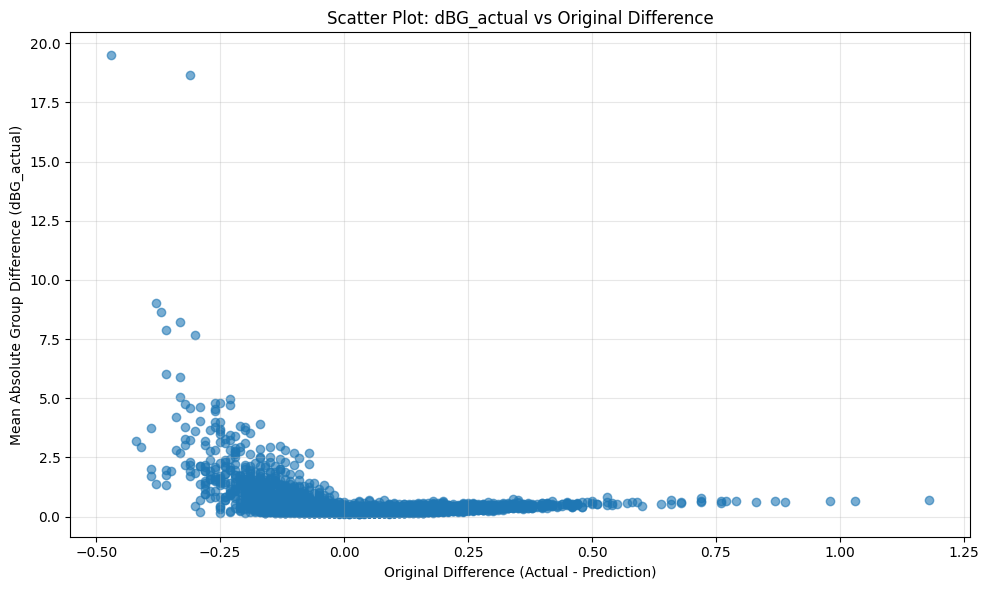

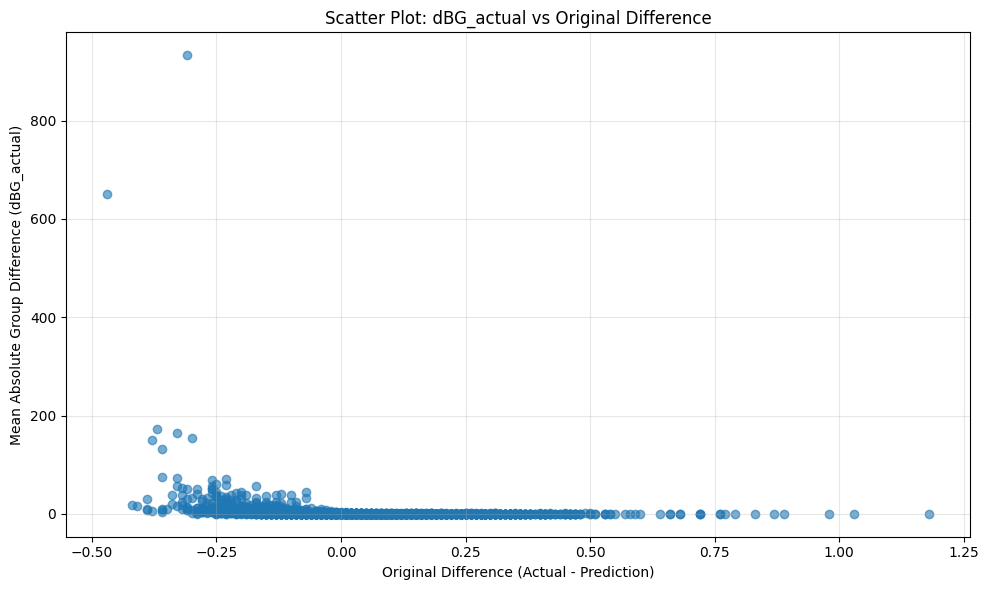

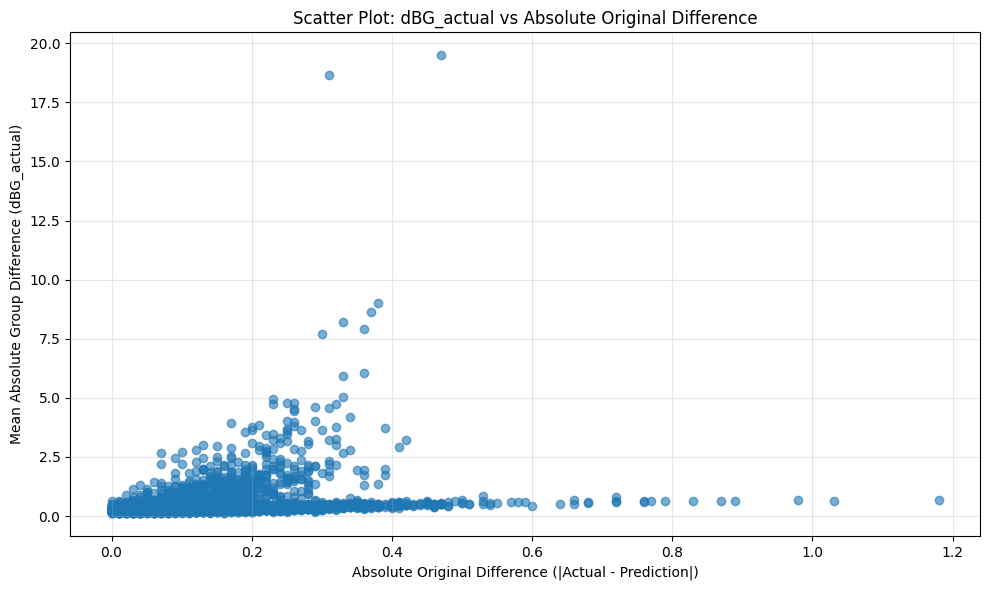

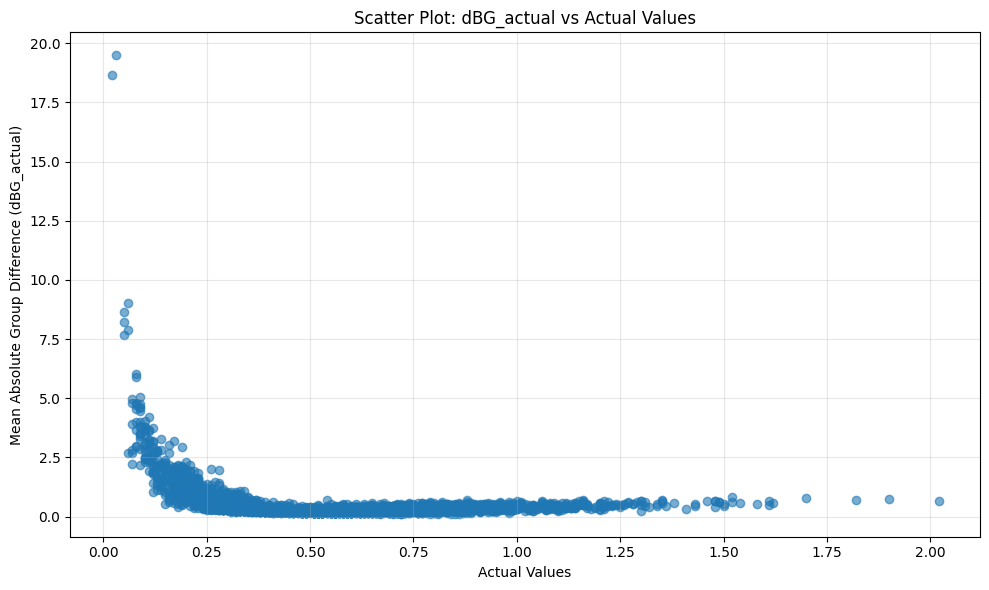

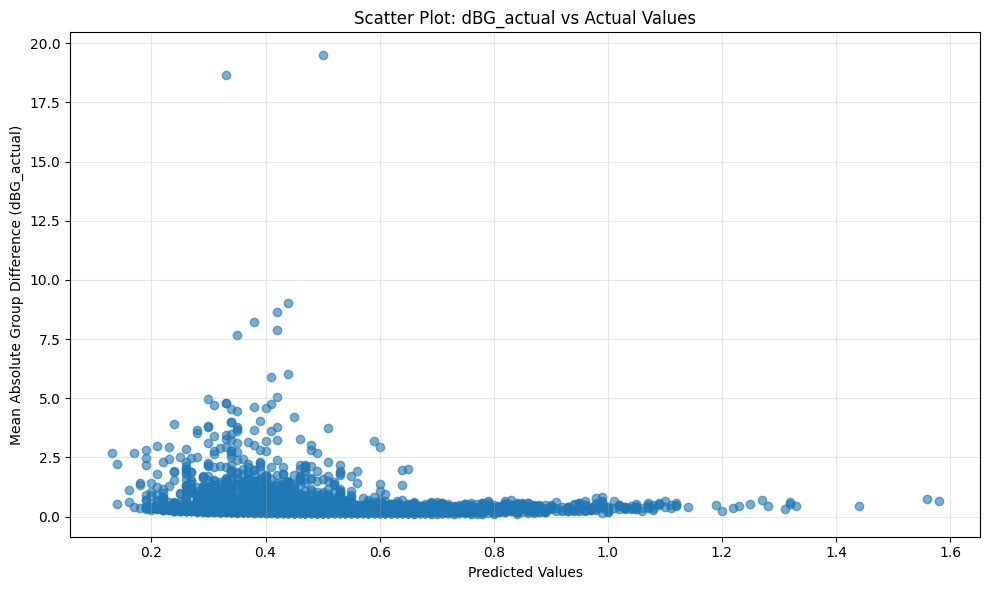

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(originalDiff, dBG_actual, alpha=0.6)
plt.xlabel('Original Difference (Actual - Prediction)')
plt.ylabel('Mean Absolute Group Difference (dBG_actual)')
plt.title('Scatter Plot: dBG_actual vs Original Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(originalDiff, [x/a[0] if x > 0 else 0 for x, a in zip(dBG_actual, actual_pred)], alpha=0.6)
plt.xlabel('Original Difference (Actual - Prediction)')
plt.ylabel('Mean Absolute Group Difference (dBG_actual)')
plt.title('Scatter Plot: dBG_actual vs Original Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(np.abs(originalDiff), dBG_actual, alpha=0.6)
plt.xlabel('Absolute Original Difference (|Actual - Prediction|)')
plt.ylabel('Mean Absolute Group Difference (dBG_actual)')
plt.title('Scatter Plot: dBG_actual vs Absolute Original Difference')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter([a[0] for a in actual_pred], dBG_actual, alpha=0.6)
plt.xlabel('Actual Values')
plt.ylabel('Mean Absolute Group Difference (dBG_actual)')
plt.title('Scatter Plot: dBG_actual vs Actual Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter([a[1] for a in actual_pred], dBG_actual, alpha=0.6)
plt.xlabel('Predicted Values')
plt.ylabel('Mean Absolute Group Difference (dBG_actual)')
plt.title('Scatter Plot: dBG_actual vs Actual Values')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
originalDiff.index(2.02-0.99)

2991

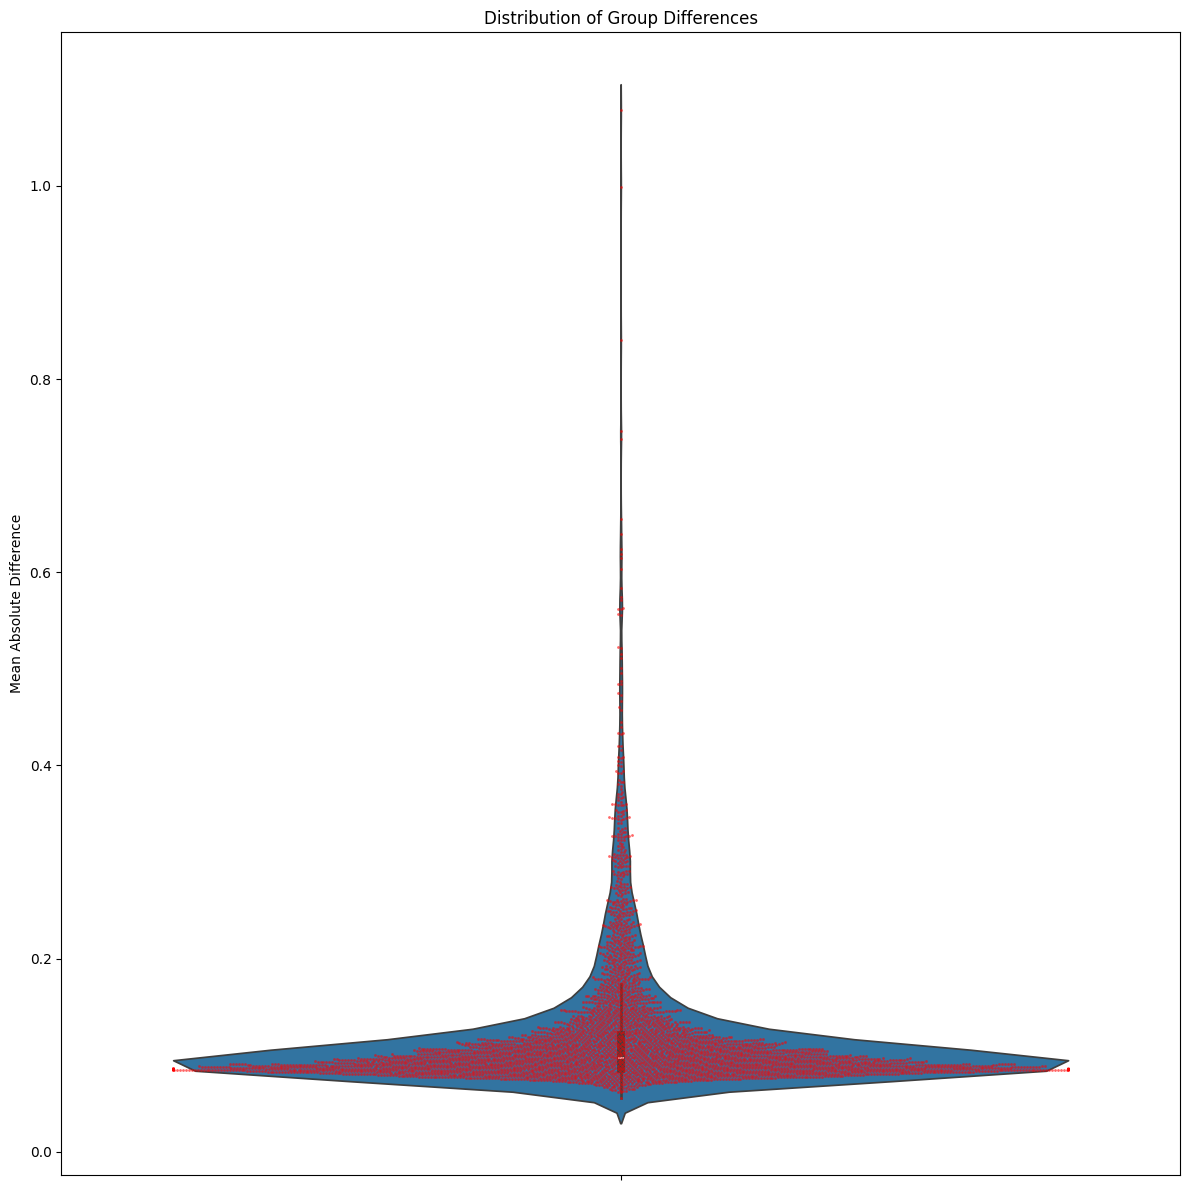

In [17]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create violin plot with swarm plot overlay
plt.figure(figsize=(12, 12))
sns.violinplot(y=dBG)
sns.swarmplot(y=dBG, color='red', alpha=0.6, size=2)
plt.ylabel('Mean Absolute Difference')
plt.title('Distribution of Group Differences')
plt.tight_layout()
plt.show()

In [9]:
print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean((seqImpact['originalPrediction'] - seqImpact['perturbedPrediction'])):.4f}")

print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean((extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction'])):.4f}")


print("\n(impact of 5UTR) :")
print(f"  {np.mean((utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean((utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction'])):.4f}")


(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0018
(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.0017

(impact of 5UTR) :
  0.0123

(impact of 3UTR) :
  0.0125


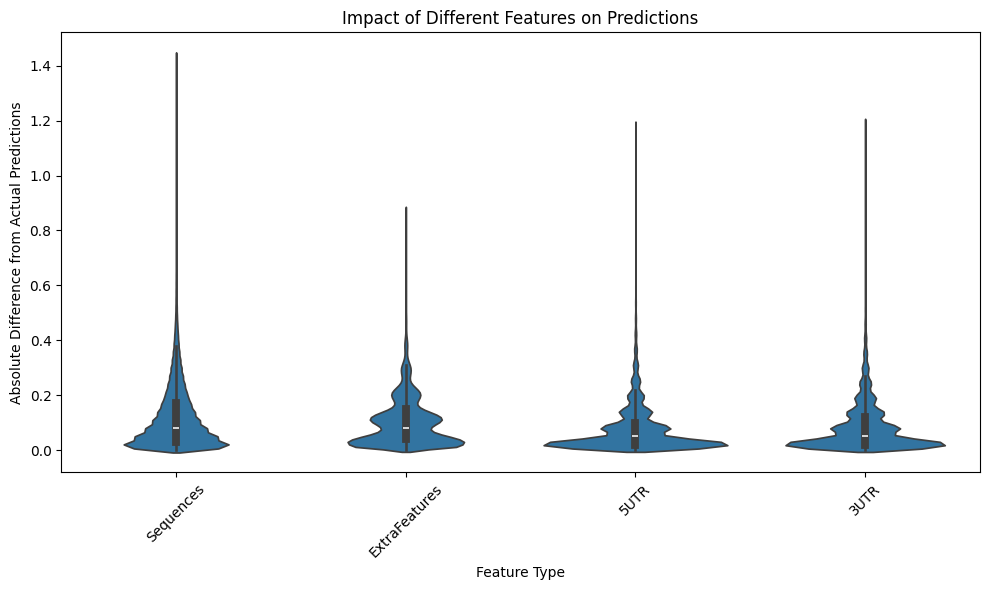

In [7]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_sequences = abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_sequences) + list(impact_extraFeatures) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['Sequences'] * len(impact_sequences) + 
               ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

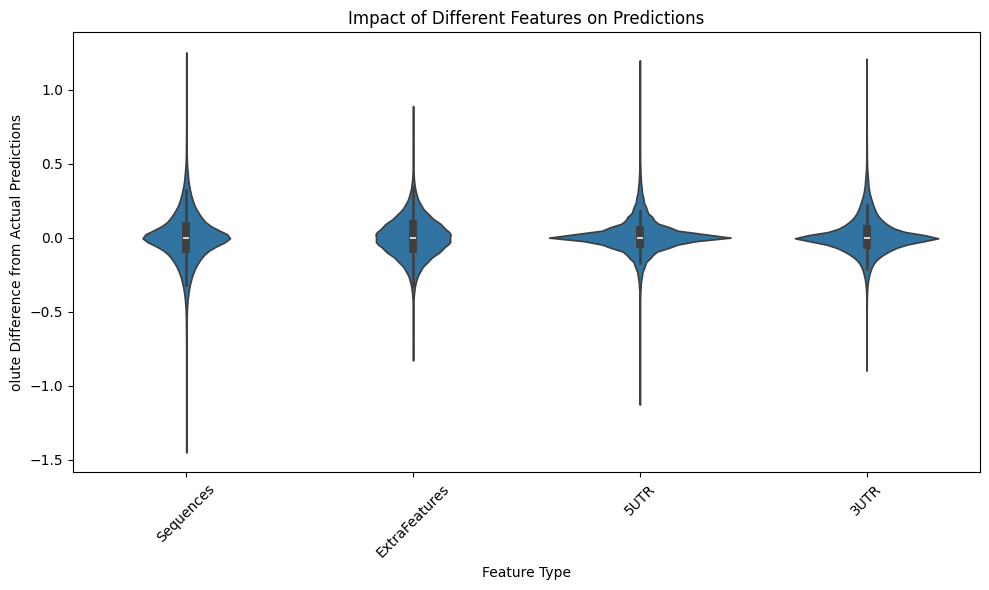

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_sequences = (seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = (extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = (utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = (utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_sequences) + list(impact_extraFeatures) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['Sequences'] * len(impact_sequences) + 
               ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('olute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Calculate impacts (reusing the calculations from cell 13 but with absolute values)
impact_sequences = abs(seqImpact['originalPrediction'] - seqImpact['perturbedPrediction']).dropna()
impact_extraFeatures = abs(extraFeatImpact['originalPrediction'] - extraFeatImpact['perturbedPrediction']).dropna()
impact_5UTR = abs(utr5Impact['originalPrediction'] - utr5Impact['perturbedPrediction']).dropna()
impact_3UTR = abs(utr3Impact['originalPrediction'] - utr3Impact['perturbedPrediction']).dropna()

# Store impacts in a dictionary for easier access
impacts = {
    'ExtraFeatures': impact_extraFeatures,
    'Sequences': impact_sequences,
    '5UTR': impact_5UTR,
    '3UTR': impact_3UTR
}

# Kruskal-Wallis test (non-parametric ANOVA)
print("Kruskal-Wallis Test (overall significance):")
h_stat, p_value = kruskal(*impacts.values())
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "="*50)
print("Pairwise Mann-Whitney U Tests:")
print("="*50)

# Pairwise comparisons using Mann-Whitney U test
feature_names = list(impacts.keys())
for i, feature1 in enumerate(feature_names):
    for j, feature2 in enumerate(feature_names[i+1:], i+1):
        u_stat, p_val = mannwhitneyu(impacts[feature1], impacts[feature2], alternative='two-sided')
        print(f"{feature1} vs {feature2}:")
        print(f"  U-statistic: {u_stat:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        print()

Kruskal-Wallis Test (overall significance):
H-statistic: 2978963.4331
p-value: 0.0000
Significant: Yes

Pairwise Mann-Whitney U Tests:
ExtraFeatures vs Sequences:
  U-statistic: 155673054901295.5000
  p-value: 0.0000
  Significant: Yes

ExtraFeatures vs 5UTR:
  U-statistic: 201890457708820.5000
  p-value: 0.0000
  Significant: Yes

ExtraFeatures vs 3UTR:
  U-statistic: 190537734346447.5000
  p-value: 0.0000
  Significant: Yes

Sequences vs 5UTR:
  U-statistic: 199877978589500.0000
  p-value: 0.0000
  Significant: Yes

Sequences vs 3UTR:
  U-statistic: 189575736402044.0000
  p-value: 0.0000
  Significant: Yes

5UTR vs 3UTR:
  U-statistic: 148998155482865.5000
  p-value: 0.0000
  Significant: Yes



In [11]:
p_value

0.0

In [4]:
merged

,originalPrediction_seqImpact,perturbedPrediction_seqImpact,sequenceCount,originalPrediction_extraFeatImpact,perturbedPrediction_extraFeatImpact,originalPrediction,perturbedPrediction,originalPrediction_utr3Impact,perturbedPrediction_utr3Impact
0,0.36,0.82,1,NaN,NaN,0.36,0.45,0.36,0.34
1,0.36,0.58,2,NaN,NaN,0.36,0.41,0.36,0.33
2,0.36,0.81,3,NaN,NaN,0.36,0.39,0.36,0.34
3,0.36,0.61,4,NaN,NaN,0.36,0.38,0.36,0.35
4,0.36,0.30,5,NaN,NaN,0.36,0.37,0.36,0.32
...,...,...,...,...,...,...,...,...,...
17871540,NaN,NaN,17858579,NaN,NaN,NaN,NaN,0.33,0.32
17871541,NaN,NaN,17858652,NaN,NaN,NaN,NaN,0.33,0.33
17871542,NaN,NaN,17861577,NaN,NaN,NaN,NaN,0.37,0.40
17871543,NaN,NaN,17865819,NaN,NaN,NaN,NaN,0.40,0.38


In [ ]:
#importance = pickle.load(open('output/importance/shap.pkl', 'rb'))


In [ ]:
#importance[0]

Explanation(text='0.34 Pred:0.36', tokens=['', 'TCG', 'ATACTATC', 'GCG', 'AGTGC', 'TAGCTGAC', 'GCTGG', 'TCTGG', 'TTTTATT', 'TTATG', 'TTAAC', 'GGG', 'AGTGATC', 'TTGCG', 'TACAAAC', 'AATAAC', 'ACGG', 'AATCGC', 'AGTGAA', 'AGGGCG', 'TTGCACAA', 'ATGACAGTG', 'TTTTGGC', 'AAAATGCCC', 'GGGC', 'TAGTTTTG', 'ACCACG', 'TTTAGC', 'AGTGCC', 'TAGAAC', 'GC', 'AGAGTGC', 'GCG', 'ACGC', 'TAAAAC', 'AAG', 'AGAACC', 'GCG', 'ACAAAAC', 'AAAAC', 'GCGG', 'AAACGC', 'ATAAAGTG', 'AAAAAAAA', 'AACAC', 'AAACGC', 'AGACAGCG', 'AACTTTGG', 'ACACAGAC', 'AATCG', 'TAAACGC', 'ACGGGG', 'AAAAC', 'AAAGAAAA', 'ACG', 'AAGAA', '[SEP]', 'GCGG', 'AATAA', 'TGCC', 'TCTAG', 'TTATG', 'TCATT', 'AGTTAG', 'TTTTTATT', 'TATGG', 'AAGGGC', 'GG', 'TCAATATGG', 'AGAG', 'AGGCAGGG', 'ACAAAC', 'TAAAATATC', 'AAGGACG', 'ACTTTAG', 'AAAGATTGC', 'TTGGG', 'AAAGTAA', 'AGGTC', 'TTAAG', 'TTC', 'AGCATT', 'TCTC', 'TCATCC', 'TTTTAAAA', 'TCAGTTTTC', 'AGTTATG', 'TATTTCG', 'ATT', 'AGATAAGG', 'AATG', 'TAAGATC', 'AGATT', 'TTACTGC', 'ATAA', 'TGTTTAT', 'ATGTCTTTT', 'TAAA

In [6]:
counts = [x+1 for x in range(len(importance))]
actualPredictions = [imp.text.split(' ')[1].split(':')[1] for imp in importance]

ap = pd.DataFrame({'sequenceCount': counts, 'actualPredictions': actualPredictions})

# merge combined with ap
merged_df = pd.merge(ap, merged, on='sequenceCount', suffixes=('_ap',''), how='outer')

In [7]:
merged_df

,sequenceCount,actualPredictions,actualDecayRate_orig,predictedDecayRate_orig,actualDecayRate_same,predictedDecayRate_same,actualDecayRate,predictedDecayRate,actualDecayRate_utr3,predictedDecayRate_utr3
0,1,0.36,0.53,0.39,0.53,0.39,0.53,0.39,0.53,0.39
1,2,0.85,0.53,0.39,0.62,0.52,0.53,0.35,0.53,0.40
2,3,0.72,0.53,0.52,0.72,0.37,0.53,0.53,0.53,0.43
3,4,0.75,0.53,0.53,0.37,0.56,0.53,0.56,0.53,0.39
4,5,0.74,0.53,0.66,0.75,0.46,0.53,0.57,0.53,0.45
...,...,...,...,...,...,...,...,...,...,...
4208,4209,0.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4209,4210,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4210,4211,0.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4211,4212,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print(merged_df[['actualPredictions','predictedDecayRate_orig','predictedDecayRate_same','predictedDecayRate','predictedDecayRate_utr3']].to_numpy().T)

[['0.36' '0.85' '0.72' ... '0.37' '0.4' '0.3']
 [0.39 0.39 0.52 ... nan nan nan]
 [0.39 0.52 0.37 ... nan nan nan]
 [0.39 0.35 0.53 ... nan nan nan]
 [0.39 0.4 0.43 ... nan nan nan]]


In [ ]:
### Absolute Values ###

# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")
#print("(impact of EF and 5UTR) impact of 5'UTR:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3'])):.4f}")

#print("\n\nsum of 3'UTR and 5'UTR impact:")
#print(f"  {np.mean(abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_utr3']) + abs(merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1629

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1490

(impact of 5UTR) :
  0.1509

(impact of 3UTR) :
  0.1421


In [ ]:
### Pos and Negative values ###

# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the mean of the olute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig'])):.4f}")
#print("(impact of seq) impact of extraFeatures compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_orig'])):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_same'])):.4f}")
#print("(impact of extraF) impact of sequences compared to sequence predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate_same'])):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate'])):.4f}")
#print("(impact of EF and 3UTR) impact of 3'UTR compared to extraFeatures predictions:")
#print(f"  {np.mean((merged_df['predictedDecayRate_orig'][0] - merged_df['predictedDecayRate'])):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.mean((merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3'])):.4f}")

(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.0710

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.0417

(impact of 5UTR) :
  0.0866

(impact of 3UTR) :
  0.0940


In [11]:
# Convert 'actualPredictions' column to numeric, coercing errors to NaN
merged_df['actualPredictions'] = pd.to_numeric(merged_df['actualPredictions'], errors='coerce')

# Now calculate and print the median of the absolute difference with interpretable labels
print("(impact of extraFeature) impact of extraFeatures compared to sequence predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()):.4f}")

print("\n(impact of seq) impact of sequences compared to extraFeatures predictions:")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()):.4f}")

print("\n(impact of 5UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()):.4f}")

print("\n(impact of 3UTR) :")
print(f"  {np.median(abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()):.4f}")


(impact of extraFeature) impact of extraFeatures compared to sequence predictions:
  0.1300

(impact of seq) impact of sequences compared to extraFeatures predictions:
  0.1100

(impact of 5UTR) :
  0.1100

(impact of 3UTR) :
  0.1000


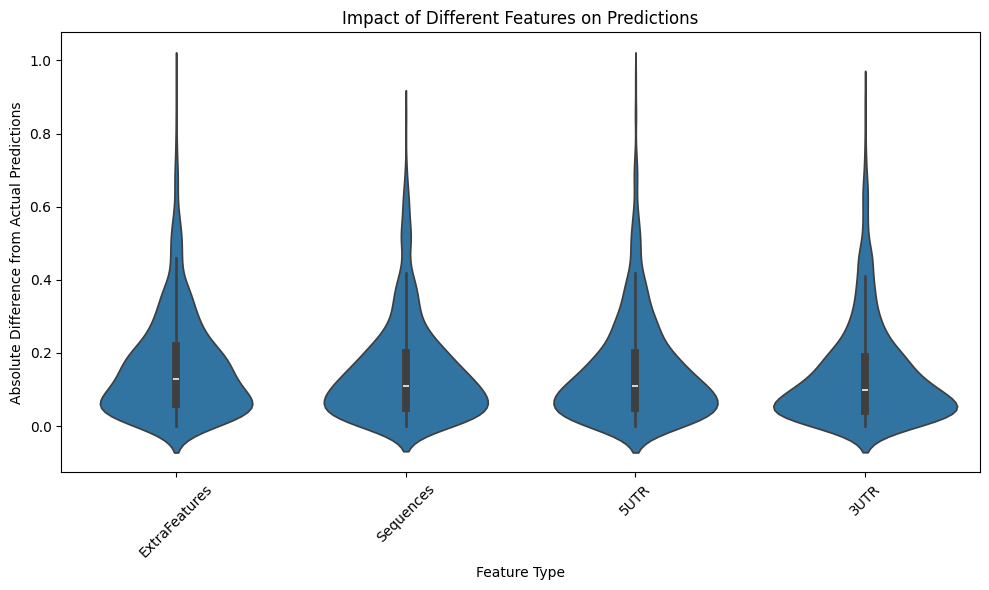

In [12]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})

# Create swarm plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

# Calculate impacts (reusing the calculations from cell 13 but with absolute values)
impact_extraFeatures = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = abs(merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Store impacts in a dictionary for easier access
impacts = {
    'ExtraFeatures': impact_extraFeatures,
    'Sequences': impact_sequences,
    '5UTR': impact_5UTR,
    '3UTR': impact_3UTR
}

# Kruskal-Wallis test (non-parametric ANOVA)
print("Kruskal-Wallis Test (overall significance):")
h_stat, p_value = kruskal(*impacts.values())
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant: {'Yes' if p_value < 0.05 else 'No'}")

print("\n" + "="*50)
print("Pairwise Mann-Whitney U Tests:")
print("="*50)

# Pairwise comparisons using Mann-Whitney U test
feature_names = list(impacts.keys())
for i, feature1 in enumerate(feature_names):
    for j, feature2 in enumerate(feature_names[i+1:], i+1):
        u_stat, p_val = mannwhitneyu(impacts[feature1], impacts[feature2], alternative='two-sided')
        print(f"{feature1} vs {feature2}:")
        print(f"  U-statistic: {u_stat:.4f}")
        print(f"  p-value: {p_val:.4f}")
        print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")
        print()

Kruskal-Wallis Test (overall significance):
H-statistic: 19.2723
p-value: 0.0002
Significant: Yes

Pairwise Mann-Whitney U Tests:
ExtraFeatures vs Sequences:
  U-statistic: 438099.5000
  p-value: 0.0184
  Significant: Yes

ExtraFeatures vs 5UTR:
  U-statistic: 436738.5000
  p-value: 0.0143
  Significant: Yes

ExtraFeatures vs 3UTR:
  U-statistic: 460520.5000
  p-value: 0.0000
  Significant: Yes

Sequences vs 5UTR:
  U-statistic: 413535.0000
  p-value: 0.8747
  Significant: No

Sequences vs 3UTR:
  U-statistic: 437426.5000
  p-value: 0.0370
  Significant: Yes

5UTR vs 3UTR:
  U-statistic: 432742.0000
  p-value: 0.0603
  Significant: No



In [28]:
import seaborn as sns

import matplotlib.pyplot as plt

# Prepare data for swarm plot
impact_data = []

# Calculate impacts and add to list
impact_extraFeatures = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_orig']).dropna()
impact_sequences = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_same']).dropna()
impact_5UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate']).dropna()
impact_3UTR = (merged_df['actualPredictions'] - merged_df['predictedDecayRate_utr3']).dropna()

# Create dataframe for plotting
plot_data = pd.DataFrame({
    'Impact': list(impact_extraFeatures) + list(impact_sequences) + list(impact_5UTR) + list(impact_3UTR),
    'Feature': ['ExtraFeatures'] * len(impact_extraFeatures) + 
               ['Sequences'] * len(impact_sequences) + 
               ['5UTR'] * len(impact_5UTR) + 
               ['3UTR'] * len(impact_3UTR)
})


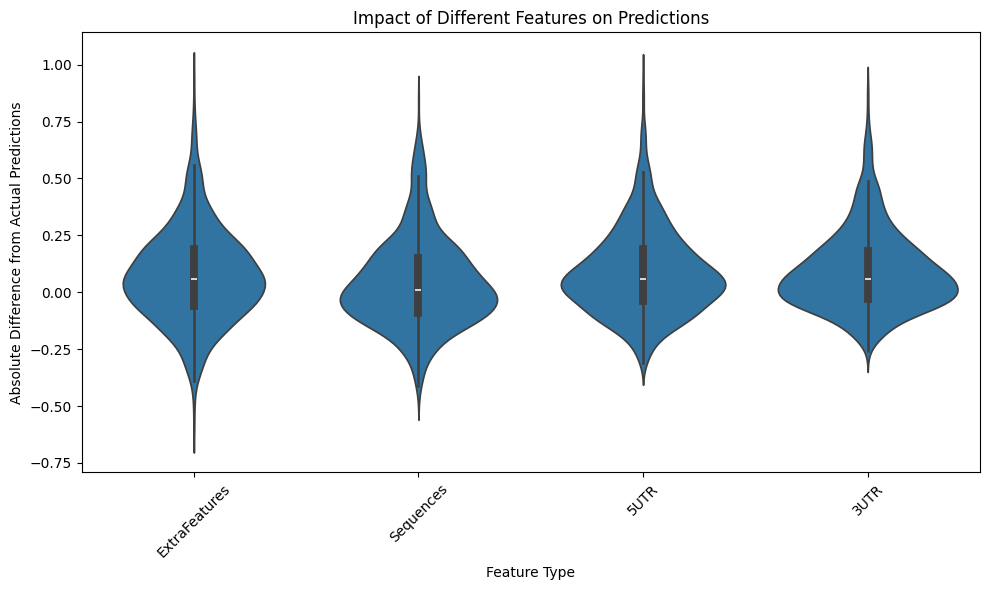

In [20]:

# Create swarm plot
plt.figure(figsize=(10, 6))
#sns.swarmplot(data=plot_data, x='Feature', y='Impact', size=3)
sns.violinplot(data=plot_data, x='Feature', y='Impact')
plt.title('Impact of Different Features on Predictions')
plt.ylabel('Absolute Difference from Actual Predictions')
plt.xlabel('Feature Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import os
import pickle

os.chdir('../..')

In [11]:
importance = pickle.load(open('output/importance/shap.pkl', 'rb'))
for imp in importance:
    imp.scores *= len(imp.scores) # this makes the scores comparable between samples of different lengths
abs_values = [float(abs(min(sample.scores))) for sample in importance] + [float(abs(max(sample.scores))) for sample in importance]

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


In [29]:
print(max(abs_values))
print(np.max(np.array(abs_values)[np.array(abs_values) < 43]))
print(np.max(np.array(abs_values)[np.array(abs_values) < 26]))
print(np.max(np.array(abs_values)[np.array(abs_values) < 14]))
print(np.array(abs_values)[np.array(abs_values) >= 10])
print(np.array(abs_values)[np.array(abs_values) >= 8.727637123988798])

43.96833557020072
26.790177751857232
14.906927818897127
12.783238865184979
[26.79017775 10.59395877 11.57401823 43.96833557 14.90692782 11.19319343
 10.27903447 10.16239664 10.26155065 10.23771394 10.97094407 10.3656599
 10.47682008 10.31937521 12.78323887 14.5425812  11.5691156  10.90390334
 12.03247716 10.81582816]
[26.79017775 10.59395877 11.57401823  8.87802378 43.96833557  8.84012966
 14.90692782 11.19319343 10.27903447  8.95733097 10.16239664 10.26155065
 10.23771394 10.97094407  9.70368114 10.3656599  10.47682008 10.31937521
 12.78323887 14.5425812  11.5691156   9.86028874 10.90390334 12.03247716
 10.81582816  9.46776119  9.29761682]


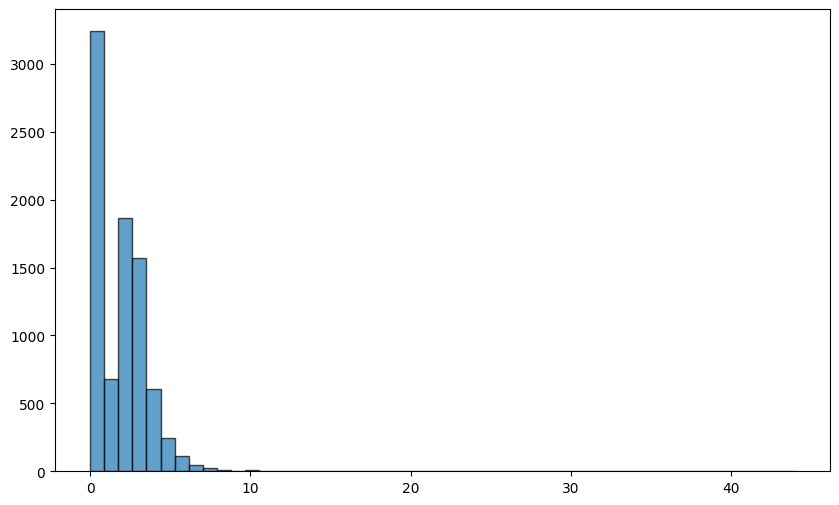

In [16]:
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

# Create combination histogram and density plot
plt.figure(figsize=(10, 6))

# Create histogram with density curve
plt.hist(abs_values, bins=50, alpha=0.7, edgecolor='black')
plt.show()


In [28]:
print(np.std(abs_values))
print(np.mean(abs_values))
print(np.mean(abs_values) + 5 * np.std(abs_values))
print(np.mean(abs_values) + 4 * np.std(abs_values))

1.719296765120718
1.8504500635059258
10.446933889109516
8.727637123988798


In [ ]:

# Add density curve
density = gaussian_kde(abs_values)
xs = np.linspace(min(abs_values), max(abs_values), 200)
plt.plot(xs, density(xs), 'r-', linewidth=2, label='Density')

plt.xlabel('Absolute SHAP Values')
plt.ylabel('Density')
plt.title('Distribution of Absolute SHAP Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some basic statistics
print(f"Mean: {np.mean(abs_values):.4f}")
print(f"Median: {np.median(abs_values):.4f}")
print(f"Standard deviation: {np.std(abs_values):.4f}")
print(f"Min: {np.min(abs_values):.4f}")
print(f"Max: {np.max(abs_values):.4f}")